In [1]:
# ── 1. SETUP & IMPORTS ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os
from pathlib import Path
from sklearn.metrics import average_precision_score, roc_auc_score
from torchdiffeq import odeint
from torch_geometric.nn import GCNConv

torch.use_deterministic_algorithms(True)
torch.set_num_threads(1)  # CPU BLAS multi-threading is not bit-reproducible across runs
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

matplotlib.rcParams.update({
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Paths ─────────────────────────────────────────────────────────────────────
DPATH    = Path('/Users/denizhan/stroke-digital-twin/data/tihm')
SAVEPATH = Path('/Users/denizhan/stroke-digital-twin/data')
RESPATH  = Path('/Users/denizhan/stroke-digital-twin/results')
FIGPATH  = Path('/Users/denizhan/stroke-digital-twin/figures')

for p in [RESPATH, FIGPATH]:
    p.mkdir(exist_ok=True)

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_SEED = 0
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'MPS' if torch.backends.mps.is_available() else 'CPU'}")
print("All imports successful.")

PyTorch version: 2.2.2
Device: CPU
All imports successful.


In [2]:
# ── 2. DATA LOADING ───────────────────────────────────────────────────────────
tihm = {
    'activity':     pd.read_csv(DPATH / 'Activity.csv',
                                parse_dates=['date'],
                                dtype={'patient_id': 'category',
                                       'location_name': 'category'}),
    'sleep':        pd.read_csv(DPATH / 'Sleep.csv',
                                parse_dates=['date'],
                                dtype={'patient_id': 'category',
                                       'state': 'category'}),
    'physiology':   pd.read_csv(DPATH / 'Physiology.csv',
                                parse_dates=['date'],
                                dtype={'patient_id': 'category',
                                       'device_type': 'category'}),
    'labels':       pd.read_csv(DPATH / 'Labels.csv',
                                parse_dates=['date'],
                                dtype={'patient_id': 'category'}),
    'demographics': pd.read_csv(DPATH / 'Demographics.csv',
                                dtype={'patient_id': 'category'}),
}

print("TIHM dataset loaded successfully.")
print(f"{'Table':15s} {'Rows':>8s}  {'Columns':>8s}")
print("-" * 35)
for name, df in tihm.items():
    print(f"{name:15s} {df.shape[0]:>8,}  {df.shape[1]:>8}")

TIHM dataset loaded successfully.
Table               Rows   Columns
-----------------------------------
activity        1,030,559         3
sleep            461,423         6
physiology        17,679         5
labels               608         3
demographics          56         3


In [3]:
# ── 3.1 FIXED FEATURE SCHEMA ─────────────────────────────────────────────────
PHYSIOLOGY_TYPES   = ['Body Temperature', 'Body weight',
                       'Diastolic blood pressure', 'Heart rate',
                       'O/E - muscle mass', 'Skin Temperature',
                       'Systolic blood pressure', 'Total body water']
SLEEP_STATES       = ['AWAKE', 'DEEP', 'LIGHT', 'REM']
ACTIVITY_LOCATIONS = ['Back Door', 'Bathroom', 'Bedroom', 'Fridge Door',
                       'Front Door', 'Hallway', 'Kitchen', 'Lounge']

PHYS_COLS       = ['phys_' + c.lower().replace(' ', '_')
                   for c in PHYSIOLOGY_TYPES]
SLEEP_STAGE_COLS = ['sleep_' + c.lower() for c in SLEEP_STATES]
SLEEP_VITAL_COLS = ['sleep_hr', 'sleep_rr']
ACT_COLS        = ['act_' + c.lower().replace(' ', '_')
                   for c in ACTIVITY_LOCATIONS]
ALL_FEATURE_COLS = PHYS_COLS + SLEEP_STAGE_COLS + SLEEP_VITAL_COLS + ACT_COLS

print(f"Total fixed feature columns: {len(ALL_FEATURE_COLS)}")
print(f"  Physiology:  {len(PHYS_COLS)} features")
print(f"  Sleep stages:{len(SLEEP_STAGE_COLS)} features")
print(f"  Sleep vitals:{len(SLEEP_VITAL_COLS)} features")
print(f"  Activity:    {len(ACT_COLS)} features")

Total fixed feature columns: 22
  Physiology:  8 features
  Sleep stages:4 features
  Sleep vitals:2 features
  Activity:    8 features


In [4]:
# ── 3.2 MODULE 1: DAILY ALIGNMENT ────────────────────────────────────────────
def build_daily_table(patient_id, tihm, study_end_date='2019-06-30'):
    """
    Aligns all TIHM streams to a shared daily time grid for one patient.
    Date range: patient's own first recorded date → study end (2019-06-30).
    All 22 features are always present via .reindex() with fill_value=0.
    """
    p     = tihm['physiology']
    p_pat = p[p.patient_id == patient_id].copy()
    p_pat['day'] = p_pat.date.dt.normalize()

    a     = tihm['activity']
    a_pat = a[a.patient_id == patient_id].copy()
    a_pat['day'] = a_pat.date.dt.normalize()

    s     = tihm['sleep']
    s_pat = s[s.patient_id == patient_id].copy()
    s_pat['day'] = s_pat.date.dt.normalize()

    earliest_dates = [d for d in [p_pat.day.min(),
                                   a_pat.day.min(),
                                   s_pat.day.min()] if pd.notna(d)]
    patient_start  = min(earliest_dates)
    patient_end    = pd.Timestamp(study_end_date)

    phys_daily = (
        p_pat.groupby(['day', 'device_type'])['value']
        .mean().unstack('device_type').reindex(columns=PHYSIOLOGY_TYPES)
    )
    phys_daily.columns = PHYS_COLS

    sleep_stages = (
        s_pat.groupby(['day', 'state']).size()
        .unstack('state', fill_value=0)
        .reindex(columns=SLEEP_STATES, fill_value=0)
    )
    sleep_stages.columns = SLEEP_STAGE_COLS
    sleep_vitals = s_pat.groupby('day')[['heart_rate',
                                         'respiratory_rate']].mean()
    sleep_vitals.columns = SLEEP_VITAL_COLS
    sleep_daily  = sleep_stages.join(sleep_vitals, how='outer')

    act_daily = (
        a_pat.groupby(['day', 'location_name']).size()
        .unstack('location_name', fill_value=0)
        .reindex(columns=ACTIVITY_LOCATIONS, fill_value=0)
    )
    act_daily.columns = ACT_COLS

    l     = tihm['labels']
    l_pat = l[l.patient_id == patient_id].copy()
    l_pat['day'] = l_pat.date.dt.normalize()
    label_daily = l_pat.groupby('day').size().rename('anomaly').clip(upper=1)

    date_range = pd.date_range(start=patient_start,
                                end=patient_end, freq='D', name='day')
    daily = (
        pd.DataFrame(index=date_range)
        .join(phys_daily,  how='left')
        .join(sleep_daily, how='left')
        .join(act_daily,   how='left')
        .join(label_daily, how='left')
    )
    daily = daily.reindex(columns=ALL_FEATURE_COLS + ['anomaly'])
    daily['anomaly']    = daily['anomaly'].fillna(0).astype(int)
    daily['patient_id'] = str(patient_id)
    return daily

print("Module 1 — build_daily_table defined.")

Module 1 — build_daily_table defined.


In [5]:
# ── 3.3 MODULE 2: MISSING VALUE IMPUTATION ───────────────────────────────────
def impute_missing(daily, calibration_days=14):
    """
    Pass 1: Forward-fill gaps ≤2 days (short sensor dropouts)
    Pass 2: Fill remaining NaNs with personal calibration mean
    Pass 3: Zero-fill any still-missing values
    """
    df = daily.copy()
    feature_cols = [c for c in df.columns
                    if c not in ['anomaly', 'patient_id']]

    df[feature_cols] = df[feature_cols].ffill(limit=2)

    cal_window = df.iloc[:calibration_days]
    cal_window = cal_window[cal_window.anomaly == 0]
    cal_means  = cal_window[feature_cols].mean()

    df[feature_cols] = df[feature_cols].fillna(cal_means)
    df[feature_cols] = df[feature_cols].fillna(0)
    return df

print("Module 2 — impute_missing defined.")

Module 2 — impute_missing defined.


In [6]:
# ── 3.4 MODULE 3: PER-PATIENT NORMALISATION ──────────────────────────────────
def normalise_patient(daily_imputed, calibration_days=14, min_std=1.0):
    """
    Z-score normalisation using only calibration window statistics.
    Personalisation step — each patient gets their own mean and std.
    Features with cal_mean == 0 are zeroed (sensor inactive during calibration).
    """
    df = daily_imputed.copy()
    feature_cols = [c for c in df.columns
                    if c not in ['anomaly', 'patient_id']]

    cal_window = df.iloc[:calibration_days]
    cal_window = cal_window[cal_window.anomaly == 0]

    cal_mean = cal_window[feature_cols].mean()
    cal_std  = cal_window[feature_cols].std()
    cal_std  = cal_std.clip(lower=min_std)

    no_signal_features = cal_mean[cal_mean == 0].index.tolist()

    df[feature_cols] = (df[feature_cols] - cal_mean) / cal_std

    

    stats = pd.DataFrame({'mean': cal_mean, 'std': cal_std})
    return df, stats, no_signal_features

print("Module 3 — normalise_patient defined.")

Module 3 — normalise_patient defined.


In [7]:
# ── 3.5 MODULE 4: TEMPORAL TRAIN/TEST SPLIT (BEFORE WINDOWING) ───────────────
def split_daily_timeline(daily_normalised, calibration_days=14, test_ratio=0.25):
    """
    Splits a patient's daily timeline into train/test segments BEFORE any
    sliding windows are created, so no 7-day window can straddle the
    train/test boundary (fixes overlapping-window leakage). Calibration
    days are excluded from both segments.
    """
    df = daily_normalised.copy()
    post_cal = df.iloc[calibration_days:].reset_index()  # 'day' becomes a column

    n = len(post_cal)
    n_train = int(n * (1 - test_ratio))
    train_daily = post_cal.iloc[:n_train].reset_index(drop=True)
    test_daily  = post_cal.iloc[n_train:].reset_index(drop=True)
    return train_daily, test_daily

print("Module 4 — split_daily_timeline defined.")


Module 4 — split_daily_timeline defined.


In [8]:
# ── 3.6 MODULE 5: SLIDING WINDOWS WITHIN AN ISOLATED SEGMENT ─────────────────
def create_windows_from_segment(daily_segment, feature_cols, window_size=7, step=1):
    """
    Builds sliding windows from an already train/test-isolated daily segment.
    Returns TWO labels per window:
      y_endpoint  — anomaly flag of the LAST day only (the clinical
                    detection target, used for test-set evaluation)
      y_any_event — 1 if ANY day in the window is anomalous (used to
                    exclude contaminated windows from "normal-only" training)
    """
    if len(daily_segment) < window_size:
        empty = torch.empty(0, window_size, len(feature_cols))
        return empty, torch.empty(0), torch.empty(0), []

    features = daily_segment[feature_cols].values
    labels   = daily_segment['anomaly'].values
    dates    = daily_segment['day'].values

    X, y_endpoint, y_any_event, window_dates = [], [], [], []
    for i in range(0, len(features) - window_size + 1, step):
        window_labels = labels[i : i + window_size]
        X.append(features[i : i + window_size])
        y_endpoint.append(window_labels[-1])
        y_any_event.append(int(window_labels.max() > 0))
        window_dates.append(dates[i + window_size - 1])

    X = torch.tensor(np.array(X), dtype=torch.float32)
    y_endpoint  = torch.tensor(np.array(y_endpoint), dtype=torch.float32)
    y_any_event = torch.tensor(np.array(y_any_event), dtype=torch.float32)
    return X, y_endpoint, y_any_event, window_dates

print("Module 5 — create_windows_from_segment defined.")


Module 5 — create_windows_from_segment defined.


In [9]:
# ── 4.1 COMPLETE PATIENT COHORT ───────────────────────────────────────────────
pts_activity   = set(tihm['activity'].patient_id.unique())
pts_sleep      = set(tihm['sleep'].patient_id.unique())
pts_physiology = set(tihm['physiology'].patient_id.unique())
pts_labels     = set(tihm['labels'].patient_id.unique())

COMPLETE_PATIENTS = sorted(
    (pts_activity & pts_sleep & pts_physiology) & pts_labels,
    key=str
)
print(f"Complete patients (all 3 streams + labels): {len(COMPLETE_PATIENTS)}")

# Check enrollment dates
print(f"\n{'Patient':12s}  {'Earliest data':15s}  {'Days after Apr 1':>16s}")
print("-" * 48)
for pid in COMPLETE_PATIENTS:
    phys_start  = tihm['physiology'][tihm['physiology'].patient_id == pid].date.min()
    act_start   = tihm['activity'][tihm['activity'].patient_id == pid].date.min()
    sleep_start = tihm['sleep'][tihm['sleep'].patient_id == pid].date.min()
    earliest    = min(d for d in [phys_start, act_start, sleep_start]
                      if pd.notna(d))
    days_after  = (earliest - pd.Timestamp('2019-04-01')).days
    print(f"{str(pid)[:12]}  {str(earliest.date()):15s}  {days_after:>16d}")

Complete patients (all 3 streams + labels): 12

Patient       Earliest data    Days after Apr 1
------------------------------------------------
16f4b  2019-04-01                      0
1fbe4  2019-04-24                     23
30a32  2019-04-26                     25
55cd4  2019-04-15                     14
93c14  2019-05-13                     42
96adf  2019-05-07                     36
a2849  2019-05-01                     30
c55f8  2019-04-01                      0
c5785  2019-04-24                     23
d7a46  2019-06-07                     67
e2472  2019-05-29                     58
ec812  2019-04-02                      1


In [10]:
# ── 4.2 DATASET OVERVIEW FIGURE ──────────────────────────────────────────────
# Uses the SAME leakage-safe pipeline as Section 5 (split before windowing,
# any-event mask for normal-only training) so this summary is consistent
# with the actual cohort construction, not a separate stale computation.
CASE_STUDY_PID_PREVIEW = '16f4b'  # matches CASE_STUDY_PID defined in Section 5

patient_summary = []
for pid in COMPLETE_PATIENTS:
    daily   = build_daily_table(pid, tihm)
    imputed = impute_missing(daily, calibration_days=14)
    normed, stats, no_signal = normalise_patient(imputed, calibration_days=14)
    feature_cols = [c for c in normed.columns if c not in ['anomaly', 'patient_id']]

    train_daily, test_daily = split_daily_timeline(
        normed, calibration_days=14, test_ratio=0.25)

    X_train_p, y_train_endpoint_p, y_train_any_p, _ = create_windows_from_segment(
        train_daily, feature_cols, window_size=7, step=1)
    X_test_p, y_test_endpoint_p, y_test_any_p, _ = create_windows_from_segment(
        test_daily, feature_cols, window_size=7, step=1)

    normal_mask = (y_train_any_p == 0)

    patient_summary.append({
        'patient_id':        str(pid)[:12],
        'total_days':        len(daily),
        'total_windows':     len(X_train_p) + len(X_test_p),
        'train_normal':      int(normal_mask.sum()),
        'test_windows':      len(X_test_p),
        'test_anomalies':    int(y_test_endpoint_p.sum()),
        'start_day':         (daily.index.min() - pd.Timestamp('2019-04-01')).days,
        'excluded_from_pool':str(pid).startswith(CASE_STUDY_PID_PREVIEW),
    })

summary_df = pd.DataFrame(patient_summary)
print("Patient summary (leakage-safe split, consistent with Section 5):")
print(summary_df.to_string(index=False))


Patient summary (leakage-safe split, consistent with Section 5):
patient_id  total_days  total_windows  train_normal  test_windows  test_anomalies  start_day  excluded_from_pool
     16f4b          91             65            20            14               0          0                True
     1fbe4          68             42            13             8               0         23               False
     30a32          66             40             0             7               1         25               False
     55cd4          77             51            27            10               0         14               False
     93c14          49             23             0             3               2         42               False
     96adf          55             29            24             5               1         36               False
     a2849          61             35             4             6               0         30               False
     c55f8          91         

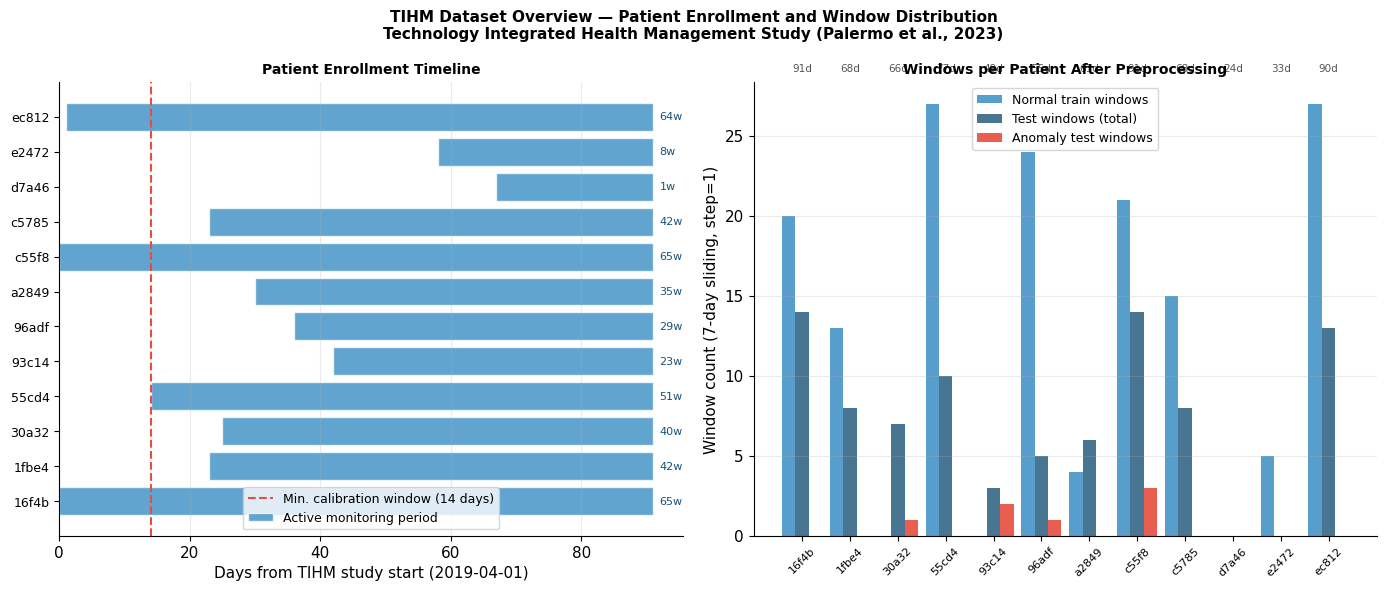

Saved fig1_dataset_overview.pdf


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'TIHM Dataset Overview — Patient Enrollment and Window Distribution\n'
    'Technology Integrated Health Management Study (Palermo et al., 2023)',
    fontsize=11, fontweight='bold'
)

# Panel 1: Enrollment timeline
ax = axes[0]
y_pos = np.arange(len(summary_df))
ax.barh(y_pos, summary_df['total_days'].values,
        left=summary_df['start_day'].values,
        color='#2E86C1', alpha=0.75, edgecolor='white',
        label='Active monitoring period')
ax.axvline(14, color='#E74C3C', ls='--', lw=1.5,
           label='Min. calibration window (14 days)')
ax.set_yticks(y_pos)
ax.set_yticklabels(summary_df['patient_id'].values, fontsize=9)
ax.set_xlabel('Days from TIHM study start (2019-04-01)')
ax.set_title('Patient Enrollment Timeline', fontsize=10, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.25, axis='x')
for i, row in summary_df.iterrows():
    ax.text(row.start_day + row.total_days + 1, i,
            f"{row.total_windows}w", va='center', fontsize=8, color='#1A5276')

# Panel 2: Window counts
ax = axes[1]
x2 = np.arange(len(summary_df))
bw = 0.28
ax.bar(x2 - bw, summary_df['train_normal'],  bw,
       color='#2E86C1', alpha=0.8, label='Normal train windows')
ax.bar(x2,       summary_df['test_windows'],  bw,
       color='#1A5276', alpha=0.8, label='Test windows (total)')
ax.bar(x2 + bw,  summary_df['test_anomalies'], bw,
       color='#E74C3C', alpha=0.9, label='Anomaly test windows')
ax.set_xticks(x2)
ax.set_xticklabels(summary_df['patient_id'].values, rotation=45, fontsize=8)
ax.set_ylabel('Window count (7-day sliding, step=1)')
ax.set_title('Windows per Patient After Preprocessing',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.25, axis='y')
for i, row in summary_df.iterrows():
    ax.text(i, summary_df['train_normal'].max() + 2,
            f"{row.total_days}d", ha='center', fontsize=7.5, color='#555')

plt.tight_layout()
plt.savefig(FIGPATH / 'fig1_dataset_overview.pdf', bbox_inches='tight', dpi=300)
plt.savefig(FIGPATH / 'fig1_dataset_overview.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved fig1_dataset_overview.pdf")

In [12]:
# ── 5. COHORT CONSTRUCTION (LEAKAGE-SAFE, CASE-STUDY PATIENT HELD OUT) ───────
all_X_normal, all_X_test, all_y_test = [], [], []
patient_normal_blocks = []   # per-patient normal windows kept separate for
                             # patient-aware conformal calibration later
patient_window_counts = []
all_test_patient_ids = []
TEST_PID_PREFIX = 'c55f8'
CASE_STUDY_PID  = '16f4b'   # excluded from pooled training below so the
                            # later case study is genuinely held-out
for pid in COMPLETE_PATIENTS:
    daily   = build_daily_table(pid, tihm)
    imputed = impute_missing(daily, calibration_days=14)
    normed, stats, no_signal = normalise_patient(imputed, calibration_days=14)
    feature_cols = [c for c in normed.columns if c not in ['anomaly', 'patient_id']]
    train_daily, test_daily = split_daily_timeline(
        normed, calibration_days=14, test_ratio=0.25)
    X_train_p, y_train_endpoint_p, y_train_any_p, _ = create_windows_from_segment(
        train_daily, feature_cols, window_size=7, step=1)
    X_test_p, y_test_endpoint_p, y_test_any_p, dates_test_p = create_windows_from_segment(
        test_daily, feature_cols, window_size=7, step=1)
    if len(X_train_p) == 0 or len(X_test_p) == 0:
        print(f"  {str(pid)[:12]}... SKIPPED (insufficient windows after split)")
        continue
    # TRUE normal-only training set: excludes any window with an event
    # ANYWHERE in its 7-day history, not just on the endpoint day
    normal_mask_p    = (y_train_any_p == 0)
    X_train_normal_p = X_train_p[normal_mask_p]
    if len(X_train_normal_p) == 0:
        print(f"  {str(pid)[:12]}... SKIPPED (no clean windows in train segment)")
        continue
    is_case_study_pid = str(pid).startswith(CASE_STUDY_PID)
    if not is_case_study_pid:
        all_X_normal.append(X_train_normal_p)
        all_X_test.append(X_test_p)
        all_y_test.append(y_test_endpoint_p)
        patient_normal_blocks.append(X_train_normal_p)
        all_test_patient_ids.append([str(pid)[:12]] * len(X_test_p))
    patient_window_counts.append({
        'patient_id':         str(pid)[:12],
        'total_days':         len(daily),
        'train_windows_raw':  len(X_train_p),
        'train_normal':       int(normal_mask_p.sum()),
        'test_windows':       len(X_test_p),
        'test_anomalies':     int(y_test_endpoint_p.sum()),
        'excluded_from_pool': is_case_study_pid,
        'no_signal_features': len(no_signal),
    })
    if str(pid).startswith(TEST_PID_PREFIX):
        X_train_normal_c55f8 = X_train_normal_p
        X_test_c55f8         = X_test_p
        y_test_c55f8         = y_test_endpoint_p
        print(f"  {str(pid)[:12]}... OK * (single-patient reference)")
    elif is_case_study_pid:
        print(f"  {str(pid)[:12]}... OK (held out - case-study patient, excluded from pool)")
    else:
        print(f"  {str(pid)[:12]}... OK")
X_train_pooled = torch.cat(all_X_normal, dim=0)
X_test_pooled  = torch.cat(all_X_test,   dim=0)
y_test_pooled  = torch.cat(all_y_test,   dim=0)
pooled_test_patient_ids = [pid for block in all_test_patient_ids for pid in block]
assert len(pooled_test_patient_ids) == len(X_test_pooled)
n_pool_patients = len(patient_normal_blocks)
print(f"\n{'='*55}")
print(f"POOLED DATASET SUMMARY (leakage-safe, {CASE_STUDY_PID} held out)")
print(f"{'='*55}")
print(f"Pooled patients:        {n_pool_patients}")
print(f"Train (normal, pooled): {X_train_pooled.shape}")
print(f"Test (pooled):          {X_test_pooled.shape}")
print(f"Test anomalies:         {int(y_test_pooled.sum())} "
      f"({y_test_pooled.mean()*100:.1f}%)")
print(f"\nSingle patient c55f8:")
print(f"Train (normal):         {X_train_normal_c55f8.shape}")
print(f"Test:                   {X_test_c55f8.shape}")
print(f"Test anomalies:         {int(y_test_c55f8.sum())}")
# Save per-patient summary (window counts, exclusions, no-signal feature
# counts) so cohort composition is independently reviewable, not just
# held transiently in memory.
patient_window_counts_df = pd.DataFrame(patient_window_counts)
patient_window_counts_df.to_csv(RESPATH / 'patient_window_counts.csv', index=False)
print(f"\nSaved patient_window_counts.csv ({len(patient_window_counts_df)} patients)")
print(patient_window_counts_df.to_string(index=False))

  16f4b... OK (held out - case-study patient, excluded from pool)
  1fbe4... OK
  30a32... SKIPPED (no clean windows in train segment)
  55cd4... OK
  93c14... SKIPPED (no clean windows in train segment)
  96adf... OK
  a2849... OK
  c55f8... OK * (single-patient reference)
  c5785... OK
  d7a46... SKIPPED (insufficient windows after split)
  e2472... SKIPPED (insufficient windows after split)
  ec812... OK

POOLED DATASET SUMMARY (leakage-safe, 16f4b held out)
Pooled patients:        7
Train (normal, pooled): torch.Size([131, 7, 22])
Test (pooled):          torch.Size([64, 7, 22])
Test anomalies:         4 (6.2%)

Single patient c55f8:
Train (normal):         torch.Size([21, 7, 22])
Test:                   torch.Size([14, 7, 22])
Test anomalies:         3

Saved patient_window_counts.csv (8 patients)
patient_id  total_days  train_windows_raw  train_normal  test_windows  test_anomalies  excluded_from_pool  no_signal_features
     16f4b          91                 51            20      

In [13]:
# ── 6.1 LSTM-VAE ──────────────────────────────────────────────────────────────
class LSTM_VAE(nn.Module):
    """
    LSTM-based Variational Autoencoder for time series anomaly detection.
    Encoder: LSTM → mu, logvar. Decoder: latent z → reconstructed sequence.
    Architecture: hidden_dim=32, latent_dim=12, seq_len=7, n_features=22.
    """
    def __init__(self, n_features=22, hidden_dim=32,
                 latent_dim=12, seq_len=7):
        super().__init__()
        self.n_features = n_features
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.seq_len    = seq_len

        self.encoder_lstm = nn.LSTM(input_size=n_features,
                                     hidden_size=hidden_dim,
                                     num_layers=1, batch_first=True)
        self.fc_mu     = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.fc_latent_to_hidden = nn.Linear(latent_dim, hidden_dim)
        self.decoder_lstm = nn.LSTM(input_size=hidden_dim,
                                     hidden_size=hidden_dim,
                                     num_layers=1, batch_first=True)
        self.fc_output = nn.Linear(hidden_dim, n_features)

    def encode(self, x):
        _, (h_n, _) = self.encoder_lstm(x)
        h_n = h_n.squeeze(0)
        return self.fc_mu(h_n), self.fc_logvar(h_n)

    def reparameterize(self, mu, logvar):
        # Deterministic at eval time: model.eval() sets self.training=False,
        # so scoring the same window twice always gives the same score.
        std = torch.exp(0.5 * logvar)
        if self.training:
            return mu + torch.randn_like(std) * std
        return mu

    def decode(self, z):
        hidden     = self.fc_latent_to_hidden(z)
        hidden_seq = hidden.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _     = self.decoder_lstm(hidden_seq)
        return self.fc_output(out)

    def forward(self, x):
        mu, logvar    = self.encode(x)
        z             = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar

print("LSTM_VAE class defined.")

LSTM_VAE class defined.


In [14]:
# ── 6.2 OMNIANOMALY ───────────────────────────────────────────────────────────
class OmniAnomaly(nn.Module):
    """
    Simplified OmniAnomaly with stochastic recurrent encoder.
    Latent z_t is conditioned on z_{t-1} — models temporal latent dynamics.
    """
    def __init__(self, n_features=22, hidden_dim=32,
                 latent_dim=12, seq_len=7):
        super().__init__()
        self.n_features = n_features
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.seq_len    = seq_len

        self.encoder_rnn = nn.GRUCell(
            input_size=n_features + latent_dim, hidden_size=hidden_dim)
        self.fc_mu     = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.decoder_rnn = nn.GRUCell(
            input_size=latent_dim, hidden_size=hidden_dim)
        self.fc_output = nn.Linear(hidden_dim, n_features)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        device = x.device

        h_enc  = torch.zeros(batch_size, self.hidden_dim,  device=device)
        h_dec  = torch.zeros(batch_size, self.hidden_dim,  device=device)
        z_prev = torch.zeros(batch_size, self.latent_dim,  device=device)

        recon_seq, mu_seq, logvar_seq = [], [], []

        for t in range(seq_len):
            x_t    = x[:, t, :]
            h_enc  = self.encoder_rnn(torch.cat([x_t, z_prev], dim=1), h_enc)
            mu_t   = self.fc_mu(h_enc)
            lv_t   = self.fc_logvar(h_enc)
            # Stochastic only during training; deterministic z_t = mu_t at
            # eval time so scoring is reproducible.
            if self.training:
                z_t = mu_t + torch.randn_like(mu_t) * torch.exp(0.5 * lv_t)
            else:
                z_t = mu_t
            h_dec  = self.decoder_rnn(z_t, h_dec)
            recon_seq.append(self.fc_output(h_dec))
            mu_seq.append(mu_t); logvar_seq.append(lv_t)
            z_prev = z_t

        return (torch.stack(recon_seq,   dim=1),
                torch.stack(mu_seq,      dim=1),
                torch.stack(logvar_seq,  dim=1))

print("OmniAnomaly class defined.")

OmniAnomaly class defined.


In [15]:
# ── 6.3 T-VAE (PROPOSED MODEL) ────────────────────────────────────────────────
class ODEFunc(nn.Module):
    """dh/dt = f(h) — time-invariant two-layer MLP."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim)
        )
    def forward(self, t, h):
        return self.net(h)


class ModalityEncoder(nn.Module):
    """LSTM encoder for one modality stream."""
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim,
                             num_layers=1, batch_first=True)
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return h_n.squeeze(0)


class TVAE(nn.Module):
    """
    T-VAE: Temporal VAE + Neural ODE + T-GNN cross-modal fusion.
    Encoder path:
      Input (batch, 7, 22)
      → 3 modality LSTM encoders → h_phys, h_sleep, h_act (each batch×32)
      → T-GNN (GCNConv × 2) → updated node representations
      → concatenate → h_fused (batch×96)
      → Neural ODE (Euler, t∈[0,1]) → h_evolved (batch×96)
      → fc_mu / fc_logvar → mu, logvar (batch×12)
      → reparameterize → z (batch×12)
      → decoder LSTM → reconstruction (batch, 7, 22)
    """
    def __init__(self, n_features=22, hidden_dim=32,
                 latent_dim=12, seq_len=7):
        super().__init__()
        self.n_features    = n_features
        self.hidden_dim    = hidden_dim
        self.latent_dim    = latent_dim
        self.seq_len       = seq_len
        self.modality_dims = [8, 8, 6]   # phys, sleep, act

        self.phys_encoder  = ModalityEncoder(self.modality_dims[0], hidden_dim)
        self.sleep_encoder = ModalityEncoder(self.modality_dims[1], hidden_dim)
        self.act_encoder   = ModalityEncoder(self.modality_dims[2], hidden_dim)

        self.gcn1 = GCNConv(hidden_dim, hidden_dim)
        self.gcn2 = GCNConv(hidden_dim, hidden_dim)
        self.edge_index = torch.tensor(
            [[0,1,0,2,1,2],[1,0,2,0,2,1]], dtype=torch.long)

        self.fused_dim = 3 * hidden_dim
        self.ode_func  = ODEFunc(self.fused_dim)
        self.t_span    = torch.linspace(0, 1, seq_len)

        self.fc_mu     = nn.Linear(self.fused_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.fused_dim, latent_dim)

        self.fc_latent_to_hidden = nn.Linear(latent_dim, hidden_dim)
        self.decoder_lstm = nn.LSTM(input_size=hidden_dim,
                                     hidden_size=hidden_dim,
                                     num_layers=1, batch_first=True)
        self.fc_output = nn.Linear(hidden_dim, n_features)

    def encode(self, x):
        device     = x.device
        batch_size = x.size(0)
        h_phys  = self.phys_encoder(x[:, :, :8])
        h_sleep = self.sleep_encoder(x[:, :, 8:16])
        h_act   = self.act_encoder(x[:, :, 16:22])

        edge_index    = self.edge_index.to(device)
        updated_nodes = []
        for b in range(batch_size):
            nf = torch.stack([h_phys[b], h_sleep[b], h_act[b]], dim=0)
            nf = torch.tanh(self.gcn1(nf, edge_index))
            nf = torch.tanh(self.gcn2(nf, edge_index))
            updated_nodes.append(nf.view(-1))
        h_fused = torch.stack(updated_nodes, dim=0)

        t_span    = self.t_span.to(device)
        h_evolved = odeint(self.ode_func, h_fused, t_span,
                           method='euler')[-1]

        return self.fc_mu(h_evolved), self.fc_logvar(h_evolved)

    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return mu

    def decode(self, z):
        hidden     = self.fc_latent_to_hidden(z)
        hidden_seq = hidden.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _     = self.decoder_lstm(hidden_seq)
        return self.fc_output(out)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

print("TVAE class defined.")

# ── Sanity check ──────────────────────────────────────────────────────────────
dummy = torch.randn(4, 7, 22)
for ModelClass, name in [(LSTM_VAE, 'LSTM_VAE'),
                          (OmniAnomaly, 'OmniAnomaly'),
                          (TVAE, 'TVAE')]:
    m    = ModelClass(n_features=22, hidden_dim=32, latent_dim=12, seq_len=7)
    r, mu, lv = m(dummy)
    assert r.shape == dummy.shape, f"{name}: recon shape mismatch"
    print(f"  {name:15s} — input {dummy.shape} → recon {r.shape} ✓")

TVAE class defined.
  LSTM_VAE        — input torch.Size([4, 7, 22]) → recon torch.Size([4, 7, 22]) ✓
  OmniAnomaly     — input torch.Size([4, 7, 22]) → recon torch.Size([4, 7, 22]) ✓
  TVAE            — input torch.Size([4, 7, 22]) → recon torch.Size([4, 7, 22]) ✓


In [16]:
# ── 6.4 TRAINING & EVALUATION FUNCTIONS ──────────────────────────────────────
def train_model(model_class, X_train_normal, n_features=22,
                hidden_dim=32, latent_dim=12, seq_len=7,
                n_epochs=100, lr=1e-3, seed=0, verbose=False):
    """
    Generic training function for LSTM_VAE, OmniAnomaly, and TVAE.
    Returns trained model and loss history dict.
    """
    torch.manual_seed(seed)
    model     = model_class(n_features=n_features, hidden_dim=hidden_dim,
                             latent_dim=latent_dim, seq_len=seq_len)
    model.train()  # explicit: ensures stochastic reparameterisation during training
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history   = {'epoch': [], 'total': [], 'recon': [], 'kl': []}

    for epoch in range(n_epochs):
        optimizer.zero_grad()
        recon, mu, logvar = model(X_train_normal)

        recon_loss = nn.functional.mse_loss(
            recon, X_train_normal, reduction='sum')
        kl_loss    = -0.5 * torch.sum(
            1 + logvar - mu.pow(2) - logvar.exp())
        total_loss = recon_loss + kl_loss

        total_loss.backward()
        optimizer.step()

        history['epoch'].append(epoch)
        history['total'].append(total_loss.item())
        history['recon'].append(recon_loss.item())
        history['kl'].append(kl_loss.item())

        if verbose and (epoch % 10 == 0 or epoch == n_epochs - 1):
            print(f'  Epoch {epoch:3d} | total: {total_loss.item():.2f} | '
                  f'recon: {recon_loss.item():.2f} | '
                  f'kl: {kl_loss.item():.2f}')

    return model, history


def get_anomaly_scores(model, X):
    """Per-window max reconstruction error across timesteps."""
    model.eval()
    with torch.no_grad():
        recon, mu, logvar = model(X)
        per_ts = ((recon - X) ** 2).mean(dim=2)   # (batch, seq_len)
        scores = per_ts.max(dim=1).values           # (batch,)
    return scores.numpy()


def evaluate_model(model, X_test, y_test):
    """Computes AUPRC, AUROC, and chance level."""
    scores    = get_anomaly_scores(model, X_test)
    y_np      = y_test.numpy()
    auprc     = average_precision_score(y_np, scores)
    auroc     = roc_auc_score(y_np, scores)
    chance    = float(y_test.float().mean())
    return {'auprc': auprc, 'auroc': auroc,
            'chance_level': chance, 'scores': scores, 'labels': y_np}


print("Training and evaluation functions defined.")

Training and evaluation functions defined.


In [17]:
# ── 7. CANONICAL 10-SEED EVALUATION ──────────────────────────────────────────
N_SEEDS = 10

# Single source of truth for condition labels — built from the ACTUAL tensors
# produced by cohort construction, never typed as literal numbers. Every
# figure/table below reuses these two variables instead of re-hardcoding text.
SINGLE_LABEL = (
    f"Single patient (c55f8, train={len(X_train_normal_c55f8)}, "
    f"test={len(X_test_c55f8)})"
)
POOLED_LABEL = (
    f"Pooled ({n_pool_patients} patients, train={len(X_train_pooled)}, "
    f"test={len(X_test_pooled)}, {CASE_STUDY_PID} held out)"
)

conditions = {
    SINGLE_LABEL: {
        'X_train': X_train_normal_c55f8,
        'X_test':  X_test_c55f8,
        'y_test':  y_test_c55f8,
    },
    POOLED_LABEL: {
        'X_train': X_train_pooled,
        'X_test':  X_test_pooled,
        'y_test':  y_test_pooled,
    },
}

model_classes = {
    'LSTM-VAE':    LSTM_VAE,
    'OmniAnomaly': OmniAnomaly,
    'T-VAE':       TVAE,
}

all_seed_results = []

for condition_name, cdata in conditions.items():
    raw_seed_results = {}
    print(f"\n{'─'*65}")
    print(f"CONDITION: {condition_name}")
    chance = float(cdata['y_test'].float().mean())
    print(f"  Chance AUPRC: {chance:.4f} | Chance AUROC: 0.5000")
    print(f"{'─'*65}")

    for model_name, ModelClass in model_classes.items():
        auroc_list, auprc_list = [], []

        for seed in range(N_SEEDS):
            model_s, _ = train_model(
                ModelClass, cdata['X_train'],
                n_features=22, hidden_dim=32, latent_dim=12,
                n_epochs=100, lr=1e-3, seed=seed, verbose=False
            )
            res_s = evaluate_model(model_s, cdata['X_test'], cdata['y_test'])
            auroc_list.append(res_s['auroc'])
            auprc_list.append(res_s['auprc'])

        auroc_arr = np.array(auroc_list)
        auprc_arr = np.array(auprc_list)

        raw_seed_results[(condition_name, model_name)] = {
            'auroc': auroc_arr, 'auprc': auprc_arr
        }

        print(f"\n  {model_name}:")
        print(f"    AUROC  median={np.median(auroc_arr):.4f}  "
              f"mean={auroc_arr.mean():.4f}  std={auroc_arr.std():.4f}")
        print(f"    AUPRC  median={np.median(auprc_arr):.4f}  "
              f"mean={auprc_arr.mean():.4f}  std={auprc_arr.std():.4f}")

        all_seed_results.append({
            'Condition':     condition_name,
            'Model':         model_name,
            'n_train':       len(cdata['X_train']),
            'n_test':        len(cdata['X_test']),
            'Chance AUPRC':  round(chance, 4),
            'Chance AUROC':  0.5000,
            'AUROC median':  round(np.median(auroc_arr), 4),
            'AUROC mean':    round(auroc_arr.mean(), 4),
            'AUROC std':     round(auroc_arr.std(), 4),
            'AUPRC median':  round(np.median(auprc_arr), 4),
            'AUPRC mean':    round(auprc_arr.mean(), 4),
            'AUPRC std':     round(auprc_arr.std(), 4),
            'Seeds':         N_SEEDS,
        })

results_df = pd.DataFrame(all_seed_results)
results_df.to_csv(RESPATH / 'table_canonical_10seed.csv', index=False)
print(f"\n\nCanonical results saved to results/table_canonical_10seed.csv")
print("\nSUMMARY TABLE (median as primary statistic):")
print(results_df[['Model', 'Condition', 'AUROC median', 'AUROC std',
                   'AUPRC median', 'AUPRC std',
                   'Chance AUPRC']].to_string(index=False))



─────────────────────────────────────────────────────────────────
CONDITION: Single patient (c55f8, train=21, test=14)
  Chance AUPRC: 0.2143 | Chance AUROC: 0.5000
─────────────────────────────────────────────────────────────────

  LSTM-VAE:
    AUROC  median=0.4848  mean=0.4909  std=0.0353
    AUPRC  median=0.2500  mean=0.2542  std=0.0160

  OmniAnomaly:
    AUROC  median=0.5758  mean=0.5758  std=0.0192
    AUPRC  median=0.2944  mean=0.2933  std=0.0089

  T-VAE:
    AUROC  median=0.5152  mean=0.5121  std=0.0286
    AUPRC  median=0.2611  mean=0.2607  std=0.0118

─────────────────────────────────────────────────────────────────
CONDITION: Pooled (7 patients, train=131, test=64, 16f4b held out)
  Chance AUPRC: 0.0625 | Chance AUROC: 0.5000
─────────────────────────────────────────────────────────────────

  LSTM-VAE:
    AUROC  median=0.5833  mean=0.5858  std=0.0112
    AUPRC  median=0.0971  mean=0.0970  std=0.0033

  OmniAnomaly:
    AUROC  median=0.6208  mean=0.6337  std=0.0229
    

In [18]:
# ── 7.1 STATISTICAL COMPARISON (bootstrap CIs + paired seed comparison) ─────
from scipy import stats as scipy_stats

def bootstrap_ci(values, n_boot=10000, seed=0):
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    boot_means = [rng.choice(values, size=len(values), replace=True).mean()
                  for _ in range(n_boot)]
    lo, hi = np.percentile(boot_means, [2.5, 97.5])
    return lo, hi

pooled_condition = [c for c in conditions.keys() if c.startswith('Pooled')][0]

print("Pooled AUROC — 95% bootstrap CI over 10 seeds (n=10 is small; treat as indicative, not precise):")
model_aurocs = {}
for model_name in model_classes.keys():
    aurocs = raw_seed_results[(pooled_condition, model_name)]['auroc']
    model_aurocs[model_name] = aurocs
    lo, hi = bootstrap_ci(aurocs)
    print(f"  {model_name:12s}: median={np.median(aurocs):.4f}  "
          f"95% CI=[{lo:.4f}, {hi:.4f}]")

print("\nPaired seed-wise comparison (same seed index across models, "
      "Wilcoxon signed-rank test):")
pairs = [('OmniAnomaly', 'T-VAE'), ('T-VAE', 'LSTM-VAE'), ('OmniAnomaly', 'LSTM-VAE')]
for a, b in pairs:
    diff = model_aurocs[a] - model_aurocs[b]
    try:
        stat, p = scipy_stats.wilcoxon(model_aurocs[a], model_aurocs[b])
    except ValueError:
        p = float('nan')
    print(f"  {a} - {b}: mean diff={diff.mean():+.4f}  "
          f"(range {diff.min():+.4f} to {diff.max():+.4f})  "
          f"Wilcoxon p={p:.4f}")

# Save for the thesis results package
ci_rows = []
for model_name, aurocs in model_aurocs.items():
    lo, hi = bootstrap_ci(aurocs)
    ci_rows.append({'Model': model_name, 'AUROC_median': np.median(aurocs),
                     'CI_lower': lo, 'CI_upper': hi})
pd.DataFrame(ci_rows).to_csv(RESPATH / 'table_pooled_auroc_ci.csv', index=False)
print("\nSaved table_pooled_auroc_ci.csv")

Pooled AUROC — 95% bootstrap CI over 10 seeds (n=10 is small; treat as indicative, not precise):
  LSTM-VAE    : median=0.5833  95% CI=[0.5792, 0.5929]
  OmniAnomaly : median=0.6208  95% CI=[0.6204, 0.6487]
  T-VAE       : median=0.5958  95% CI=[0.5904, 0.6058]

Paired seed-wise comparison (same seed index across models, Wilcoxon signed-rank test):
  OmniAnomaly - T-VAE: mean diff=+0.0358  (range -0.0042 to +0.0750)  Wilcoxon p=0.0039
  T-VAE - LSTM-VAE: mean diff=+0.0121  (range -0.0208 to +0.0333)  Wilcoxon p=0.0820
  OmniAnomaly - LSTM-VAE: mean diff=+0.0479  (range +0.0167 to +0.0875)  Wilcoxon p=0.0020

Saved table_pooled_auroc_ci.csv


In [19]:
# ── 7.2 NON-NEURAL BASELINES (PCA reconstruction error, Isolation Forest) ────
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

def flatten_windows(X):
    """(N, 7, 22) tensor -> (N, 154) numpy array for sklearn baselines."""
    return X.numpy().reshape(len(X), -1)

def eval_pca_baseline(X_train_normal, X_test, y_test, n_components=None):
    X_train_flat = flatten_windows(X_train_normal)
    X_test_flat  = flatten_windows(X_test)
    max_components = min(X_train_flat.shape[0] - 1, X_train_flat.shape[1])
    k = min(n_components or 10, max_components)
    if k < 1:
        return None  # too few normal windows to fit even 1 component
    pca = PCA(n_components=k, svd_solver='full')  # deterministic, no seed needed
    pca.fit(X_train_flat)
    recon = pca.inverse_transform(pca.transform(X_test_flat))
    scores = ((X_test_flat - recon) ** 2).mean(axis=1)
    y_np = y_test.numpy()
    return {'auroc': roc_auc_score(y_np, scores),
            'auprc': average_precision_score(y_np, scores),
            'scores': scores, 'labels': y_np, 'n_components': k}

def eval_iforest_baseline(X_train_normal, X_test, y_test, seed=0):
    X_train_flat = flatten_windows(X_train_normal)
    X_test_flat  = flatten_windows(X_test)
    iforest = IsolationForest(n_estimators=100, contamination='auto',
                               random_state=seed)
    iforest.fit(X_train_flat)
    scores = -iforest.score_samples(X_test_flat)  # higher = more anomalous
    y_np = y_test.numpy()
    return {'auroc': roc_auc_score(y_np, scores),
            'auprc': average_precision_score(y_np, scores),
            'scores': scores, 'labels': y_np}

print("Non-neural baselines:\n")
baseline_seed_results = {}

for condition_name, cdata in conditions.items():
    print(f"{'─'*65}")
    print(f"CONDITION: {condition_name}")

    # PCA — deterministic, run once (no seed variation to report)
    pca_res = eval_pca_baseline(cdata['X_train'], cdata['X_test'], cdata['y_test'])
    if pca_res is None:
        print("  PCA: SKIPPED (too few normal training windows)")
    else:
        print(f"  PCA (k={pca_res['n_components']}): "
              f"AUROC={pca_res['auroc']:.4f}  AUPRC={pca_res['auprc']:.4f}")
        all_seed_results.append({
            'Condition': condition_name, 'Model': 'PCA',
            'n_train': len(cdata['X_train']), 'n_test': len(cdata['X_test']),
            'Chance AUPRC': round(float(cdata['y_test'].float().mean()), 4),
            'Chance AUROC': 0.5000,
            'AUROC median': round(pca_res['auroc'], 4),
            'AUROC mean':   round(pca_res['auroc'], 4),
            'AUROC std':    0.0,
            'AUPRC median': round(pca_res['auprc'], 4),
            'AUPRC mean':   round(pca_res['auprc'], 4),
            'AUPRC std':    0.0,
            'Seeds': 1,
        })

    # Isolation Forest — has internal randomness, run across same 10 seeds
    iforest_aurocs, iforest_auprcs = [], []
    for seed in range(N_SEEDS):
        res = eval_iforest_baseline(cdata['X_train'], cdata['X_test'],
                                     cdata['y_test'], seed=seed)
        iforest_aurocs.append(res['auroc'])
        iforest_auprcs.append(res['auprc'])
    iforest_aurocs = np.array(iforest_aurocs)
    iforest_auprcs = np.array(iforest_auprcs)
    baseline_seed_results[(condition_name, 'IsolationForest')] = {
        'auroc': iforest_aurocs, 'auprc': iforest_auprcs
    }
    print(f"  IsolationForest: AUROC median={np.median(iforest_aurocs):.4f}  "
          f"std={iforest_aurocs.std():.4f}")
    all_seed_results.append({
        'Condition': condition_name, 'Model': 'IsolationForest',
        'n_train': len(cdata['X_train']), 'n_test': len(cdata['X_test']),
        'Chance AUPRC': round(float(cdata['y_test'].float().mean()), 4),
        'Chance AUROC': 0.5000,
        'AUROC median': round(np.median(iforest_aurocs), 4),
        'AUROC mean':   round(iforest_aurocs.mean(), 4),
        'AUROC std':    round(iforest_aurocs.std(), 4),
        'AUPRC median': round(np.median(iforest_auprcs), 4),
        'AUPRC mean':   round(iforest_auprcs.mean(), 4),
        'AUPRC std':    round(iforest_auprcs.std(), 4),
        'Seeds': N_SEEDS,
    })
    print()

# Rebuild results_df to include the new baseline rows, re-save
results_df = pd.DataFrame(all_seed_results)
results_df.to_csv(RESPATH / 'table_canonical_10seed.csv', index=False)
print("Updated table_canonical_10seed.csv now includes PCA and IsolationForest rows.")
print(results_df[['Model', 'Condition', 'AUROC median', 'AUROC std',
                   'AUPRC median', 'Chance AUPRC']].to_string(index=False))

Non-neural baselines:

─────────────────────────────────────────────────────────────────
CONDITION: Single patient (c55f8, train=21, test=14)
  PCA (k=10): AUROC=0.5455  AUPRC=0.2854
  IsolationForest: AUROC median=0.4545  std=0.1014

─────────────────────────────────────────────────────────────────
CONDITION: Pooled (7 patients, train=131, test=64, 16f4b held out)
  PCA (k=10): AUROC=0.6292  AUPRC=0.1998
  IsolationForest: AUROC median=0.4896  std=0.0835

Updated table_canonical_10seed.csv now includes PCA and IsolationForest rows.
          Model                                               Condition  AUROC median  AUROC std  AUPRC median  Chance AUPRC
       LSTM-VAE               Single patient (c55f8, train=21, test=14)         0.485      0.035         0.250         0.214
    OmniAnomaly               Single patient (c55f8, train=21, test=14)         0.576      0.019         0.294         0.214
          T-VAE               Single patient (c55f8, train=21, test=14)         0.515 

In [20]:
# ── STEP 1: VALIDATE PCA k CHOICE (training-only, documented) ───────────────
print("PCA k VALIDATION")
print("="*60)
print("k=10 was an arbitrary default in eval_pca_baseline() — never selected "
      "by comparing AUROC across k values on the test set. Below: explained "
      "variance at k=10 (documentation), plus a principled TRAINING-ONLY "
      "choice via a 90% cumulative explained-variance threshold.")

pca_k90_results = {}
for condition_name, cdata in conditions.items():
    X_train_flat = flatten_windows(cdata['X_train'])
    max_k = min(X_train_flat.shape[0] - 1, X_train_flat.shape[1])
    pca_full = PCA(n_components=max_k, svd_solver='full')
    pca_full.fit(X_train_flat)
    cum_var = np.cumsum(pca_full.explained_variance_ratio_)

    k10 = min(10, max_k)
    var_at_10 = cum_var[k10 - 1]
    k90 = int(np.argmax(cum_var >= 0.90) + 1) if (cum_var >= 0.90).any() else max_k

    print(f"\n{condition_name}")
    print(f"  Max feasible k: {max_k}")
    print(f"  Explained variance at k=10: {var_at_10:.1%}")
    print(f"  Training-only k for >=90% variance: k={k90} ({cum_var[k90-1]:.1%})")

    pca_res_k90 = eval_pca_baseline(cdata['X_train'], cdata['X_test'],
                                     cdata['y_test'], n_components=k90)
    pca_k90_results[condition_name] = pca_res_k90
    print(f"  PCA (k={k90}, training-only): AUROC={pca_res_k90['auroc']:.4f}  "
          f"AUPRC={pca_res_k90['auprc']:.4f}")

    print(f"  Sensitivity sweep (documentation only, NOT used for selection):")
    for k_try in sorted(set([2, 5, 10, 15, 20, k90])):
        if k_try > max_k:
            continue
        res_k = eval_pca_baseline(cdata['X_train'], cdata['X_test'],
                                   cdata['y_test'], n_components=k_try)
        print(f"    k={k_try:3d}: AUROC={res_k['auroc']:.4f}  AUPRC={res_k['auprc']:.4f}")

# ── Replace PCA rows in results_df with the principled training-only k ─────
results_df = results_df[results_df['Model'] != 'PCA'].copy()

for condition_name, cdata in conditions.items():
    pca_res = pca_k90_results[condition_name]
    results_df = pd.concat([results_df, pd.DataFrame([{
        'Condition': condition_name, 'Model': 'PCA',
        'n_train': len(cdata['X_train']), 'n_test': len(cdata['X_test']),
        'Chance AUPRC': round(float(cdata['y_test'].float().mean()), 4),
        'Chance AUROC': 0.5000,
        'AUROC median': round(pca_res['auroc'], 4),
        'AUROC mean':   round(pca_res['auroc'], 4),
        'AUROC std':    0.0,
        'AUPRC median': round(pca_res['auprc'], 4),
        'AUPRC mean':   round(pca_res['auprc'], 4),
        'AUPRC std':    0.0,
        'Seeds': 1,
    }])], ignore_index=True)

results_df.to_csv(RESPATH / 'table_canonical_10seed.csv', index=False)
print("PCA rows replaced with training-only k (documented in Step 1). "
      "table_canonical_10seed.csv updated.")
print(results_df[results_df['Model'].isin(['PCA', 'OmniAnomaly'])]
      [['Model', 'Condition', 'AUROC median', 'AUPRC median']].to_string(index=False))


PCA k VALIDATION
k=10 was an arbitrary default in eval_pca_baseline() — never selected by comparing AUROC across k values on the test set. Below: explained variance at k=10 (documentation), plus a principled TRAINING-ONLY choice via a 90% cumulative explained-variance threshold.

Single patient (c55f8, train=21, test=14)
  Max feasible k: 20
  Explained variance at k=10: 77.8%
  Training-only k for >=90% variance: k=15 (91.6%)
  PCA (k=15, training-only): AUROC=0.4242  AUPRC=0.2407
  Sensitivity sweep (documentation only, NOT used for selection):
    k=  2: AUROC=0.4242  AUPRC=0.2407
    k=  5: AUROC=0.4848  AUPRC=0.2619
    k= 10: AUROC=0.5455  AUPRC=0.2854
    k= 15: AUROC=0.4242  AUPRC=0.2407
    k= 20: AUROC=0.4545  AUPRC=0.2500

Pooled (7 patients, train=131, test=64, 16f4b held out)
  Max feasible k: 130
  Explained variance at k=10: 53.7%
  Training-only k for >=90% variance: k=50 (90.1%)
  PCA (k=50, training-only): AUROC=0.6792  AUPRC=0.3363
  Sensitivity sweep (documentation 

In [21]:
# ── STEP 2: VERIFY ALL MODELS HAVE FULL COLUMN SET ──────────────────────────
required_cols = ['Model', 'Condition', 'AUROC median', 'AUROC std',
                  'AUPRC median', 'AUPRC std', 'Chance AUPRC']
print(results_df[required_cols].to_string(index=False))

          Model                                               Condition  AUROC median  AUROC std  AUPRC median  AUPRC std  Chance AUPRC
       LSTM-VAE               Single patient (c55f8, train=21, test=14)         0.485      0.035         0.250      0.016         0.214
    OmniAnomaly               Single patient (c55f8, train=21, test=14)         0.576      0.019         0.294      0.009         0.214
          T-VAE               Single patient (c55f8, train=21, test=14)         0.515      0.029         0.261      0.012         0.214
       LSTM-VAE Pooled (7 patients, train=131, test=64, 16f4b held out)         0.583      0.011         0.097      0.003         0.062
    OmniAnomaly Pooled (7 patients, train=131, test=64, 16f4b held out)         0.621      0.023         0.114      0.014         0.062
          T-VAE Pooled (7 patients, train=131, test=64, 16f4b held out)         0.596      0.012         0.101      0.002         0.062
IsolationForest               Single patient (c5

In [22]:
# ── STEP 3: SAVE RAW PER-WINDOW SCORES, ALL 10 SEEDS, ALL NEURAL MODELS ─────
raw_seed_scores = {}

for condition_name, cdata in conditions.items():
    for model_name, ModelClass in model_classes.items():
        seed_scores = []
        for seed in range(N_SEEDS):
            model_s, _ = train_model(
                ModelClass, cdata['X_train'],
                n_features=22, hidden_dim=32, latent_dim=12,
                n_epochs=100, lr=1e-3, seed=seed, verbose=False
            )
            res_s = evaluate_model(model_s, cdata['X_test'], cdata['y_test'])
            seed_scores.append(res_s['scores'])
        raw_seed_scores[(condition_name, model_name)] = np.array(seed_scores)

        recomputed_aurocs = [roc_auc_score(cdata['y_test'].numpy(), s) for s in seed_scores]

        # Optional consistency check against Section 7.1's raw_seed_results —
        # only runs if that key still exists; won't block Step 3 if it doesn't
        key = (condition_name, model_name)
        if 'raw_seed_results' in dir() and key in raw_seed_results:
            stored_aurocs = raw_seed_results[key]['auroc']
            if np.allclose(recomputed_aurocs, stored_aurocs):
                check_msg = "matches Section 7.1"
            else:
                check_msg = "MISMATCH vs Section 7.1 — re-run Section 7 to refresh"
        else:
            check_msg = "no Section 7.1 reference found (skipped check)"

        print(f"{condition_name[:25]:25s} {model_name:12s}: "
              f"scores shape {raw_seed_scores[key].shape}  [{check_msg}]")

np.savez(RESPATH / 'raw_seed_scores_pooled.npz',
    **{f"{cond[:4]}_{model}": raw_seed_scores[(cond, model)]
       for cond in conditions for model in model_classes})
print("\nSaved raw_seed_scores_pooled.npz")

Single patient (c55f8, tr LSTM-VAE    : scores shape (10, 14)  [no Section 7.1 reference found (skipped check)]
Single patient (c55f8, tr OmniAnomaly : scores shape (10, 14)  [no Section 7.1 reference found (skipped check)]
Single patient (c55f8, tr T-VAE       : scores shape (10, 14)  [no Section 7.1 reference found (skipped check)]
Pooled (7 patients, train LSTM-VAE    : scores shape (10, 64)  [matches Section 7.1]
Pooled (7 patients, train OmniAnomaly : scores shape (10, 64)  [matches Section 7.1]
Pooled (7 patients, train T-VAE       : scores shape (10, 64)  [matches Section 7.1]

Saved raw_seed_scores_pooled.npz


In [23]:
# ── STEP 4: UNCERTAINTY ANALYSIS (self-contained — includes bootstrap function) ─
def bootstrap_auroc_ci_testset(scores, labels, n_boot=10000, seed=0):
    """Resamples TEST WINDOWS (not model seeds) — appropriate for PCA, which
    has no training randomness of its own to bootstrap over."""
    rng = np.random.default_rng(seed)
    scores, labels = np.asarray(scores), np.asarray(labels)
    n = len(scores)
    boot_aurocs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(labels[idx])) < 2:
            continue  # skip resamples with only one class present
        boot_aurocs.append(roc_auc_score(labels[idx], scores[idx]))
    lo, hi = np.percentile(boot_aurocs, [2.5, 97.5])
    return lo, hi, len(boot_aurocs)

pooled_condition = [c for c in conditions.keys() if c.startswith('Pooled')][0]
pca_final = pca_k90_results[pooled_condition]   # training-only k=50

# 1. PCA test-window bootstrap CI
lo, hi, n_valid = bootstrap_auroc_ci_testset(pca_final['scores'], pca_final['labels'])
print("[PCA TEST-WINDOW BOOTSTRAP 95% CI — resamples test windows, NOT model "
      "seeds, since PCA has no training randomness]")
print(f"PCA pooled AUROC: {pca_final['auroc']:.4f}  95% CI: [{lo:.4f}, {hi:.4f}]  "
      f"(n={n_valid} valid resamples)")

# 2. Paired PCA vs OmniAnomaly — PCA is fixed, compare against all 10 seeds
omni_aurocs = np.array([roc_auc_score(conditions[pooled_condition]['y_test'].numpy(), s)
                         for s in raw_seed_scores[(pooled_condition, 'OmniAnomaly')]])
diffs_omni = omni_aurocs - pca_final['auroc']
_, p_omni = scipy_stats.wilcoxon(diffs_omni)
print(f"\n[PCA vs OmniAnomaly — all 10 OmniAnomaly seeds vs PCA's fixed AUROC]")
print(f"  OmniAnomaly seed AUROCs: {np.round(omni_aurocs, 4)}")
print(f"  Diffs from PCA ({pca_final['auroc']:.4f}): {np.round(diffs_omni, 4)}")
print(f"  Mean diff={diffs_omni.mean():+.4f}  Wilcoxon (vs 0) p={p_omni:.4f}")

# 3. Paired PCA vs T-VAE
tvae_aurocs = np.array([roc_auc_score(conditions[pooled_condition]['y_test'].numpy(), s)
                         for s in raw_seed_scores[(pooled_condition, 'T-VAE')]])
diffs_tvae = tvae_aurocs - pca_final['auroc']
_, p_tvae = scipy_stats.wilcoxon(diffs_tvae)
print(f"\n[PCA vs T-VAE — all 10 T-VAE seeds vs PCA's fixed AUROC]")
print(f"  T-VAE seed AUROCs: {np.round(tvae_aurocs, 4)}")
print(f"  Diffs from PCA ({pca_final['auroc']:.4f}): {np.round(diffs_tvae, 4)}")
print(f"  Mean diff={diffs_tvae.mean():+.4f}  Wilcoxon (vs 0) p={p_tvae:.4f}")

[PCA TEST-WINDOW BOOTSTRAP 95% CI — resamples test windows, NOT model seeds, since PCA has no training randomness]
PCA pooled AUROC: 0.6792  95% CI: [0.3387, 1.0000]  (n=9849 valid resamples)

[PCA vs OmniAnomaly — all 10 OmniAnomaly seeds vs PCA's fixed AUROC]
  OmniAnomaly seed AUROCs: [0.675  0.6167 0.6625 0.6167 0.6208 0.6083 0.65   0.6542 0.6208 0.6125]
  Diffs from PCA (0.6792): [-0.0042 -0.0625 -0.0167 -0.0625 -0.0583 -0.0708 -0.0292 -0.025  -0.0583
 -0.0667]
  Mean diff=-0.0454  Wilcoxon (vs 0) p=0.0020

[PCA vs T-VAE — all 10 T-VAE seeds vs PCA's fixed AUROC]
  T-VAE seed AUROCs: [0.6    0.5917 0.5917 0.5875 0.6083 0.5833 0.6    0.6167 0.5833 0.6167]
  Diffs from PCA (0.6792): [-0.0792 -0.0875 -0.0875 -0.0917 -0.0708 -0.0958 -0.0792 -0.0625 -0.0958
 -0.0625]
  Mean diff=-0.0813  Wilcoxon (vs 0) p=0.0020


In [24]:
# ── STEP 5: PER-PATIENT POOLED TEST BREAKDOWN ───────────────────────────────
pooled_test_patient_ids_arr = np.array(pooled_test_patient_ids)
y_test_np_pooled = y_test_pooled.numpy()

# seed=0 scores for OmniAnomaly and T-VAE, from Step 3's saved raw_seed_scores
omni_scores_seed0 = raw_seed_scores[(pooled_condition, 'OmniAnomaly')][0]
tvae_scores_seed0 = raw_seed_scores[(pooled_condition, 'T-VAE')][0]
pca_scores = pca_final['scores']   # from Step 1, k=50 training-only

def safe_auroc_auprc(labels, scores):
    if len(np.unique(labels)) < 2:
        return "Not defined", "Not defined"
    return (round(roc_auc_score(labels, scores), 4),
            round(average_precision_score(labels, scores), 4))

per_patient_rows = []
for pid in sorted(set(pooled_test_patient_ids_arr)):
    mask = pooled_test_patient_ids_arr == pid
    labels_p = y_test_np_pooled[mask]
    pca_auroc_p, pca_auprc_p = safe_auroc_auprc(labels_p, pca_scores[mask])
    omni_auroc_p, _ = safe_auroc_auprc(labels_p, omni_scores_seed0[mask])
    tvae_auroc_p, _ = safe_auroc_auprc(labels_p, tvae_scores_seed0[mask])
    per_patient_rows.append({
        'Patient': pid,
        'Test windows': int(mask.sum()),
        'Positive endpoint alerts': int(labels_p.sum()),
        'PCA AUROC': pca_auroc_p, 'PCA AUPRC': pca_auprc_p,
        'OmniAnomaly AUROC': omni_auroc_p,
        'T-VAE AUROC': tvae_auroc_p,
    })

per_patient_df = pd.DataFrame(per_patient_rows)
print(per_patient_df.to_string(index=False))
per_patient_df.to_csv(RESPATH / 'table_per_patient_pooled_test.csv', index=False)
print("\nSaved table_per_patient_pooled_test.csv")

Patient  Test windows  Positive endpoint alerts   PCA AUROC   PCA AUPRC OmniAnomaly AUROC T-VAE AUROC
  1fbe4             8                         0 Not defined Not defined       Not defined Not defined
  55cd4            10                         0 Not defined Not defined       Not defined Not defined
  96adf             5                         1       0.500       0.333             1.000       0.500
  a2849             6                         0 Not defined Not defined       Not defined Not defined
  c55f8            14                         3       0.576       0.512             0.606       0.606
  c5785             8                         0 Not defined Not defined       Not defined Not defined
  ec812            13                         0 Not defined Not defined       Not defined Not defined

Saved table_per_patient_pooled_test.csv


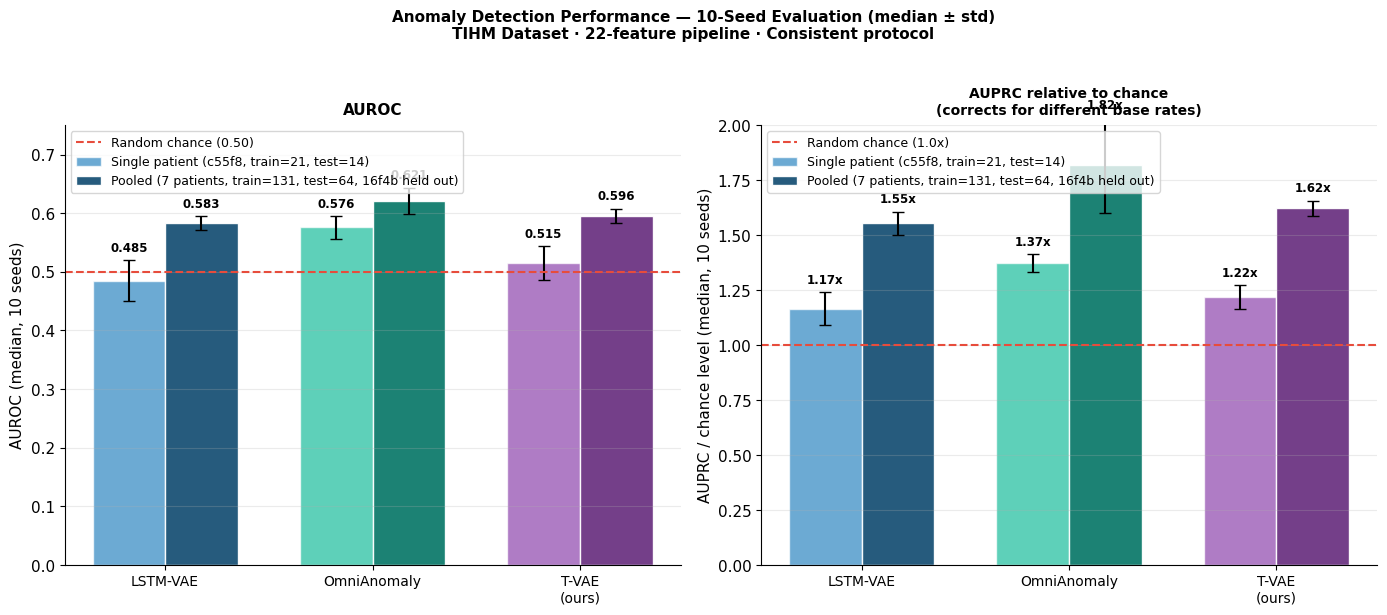

Saved fig2_canonical_results.pdf


In [25]:
# ── FIGURE 2: CANONICAL RESULTS ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Anomaly Detection Performance — 10-Seed Evaluation (median ± std)\n'
    'TIHM Dataset · 22-feature pipeline · Consistent protocol',
    fontsize=11, fontweight='bold', y=1.02
)

models     = ['LSTM-VAE', 'OmniAnomaly', 'T-VAE\n(ours)']
x          = np.arange(len(models))
width      = 0.35
colors_s   = ['#2E86C1', '#1ABC9C', '#8E44AD']
colors_p   = ['#1A5276', '#0F7B6C', '#6C3483']

# Extract from results_df
def get_vals(condition, metric):
    rows = results_df[results_df['Condition'].str.startswith(
        condition.split('(')[0].strip())]
    return [rows[rows.Model == m][metric].values[0]
            for m in ['LSTM-VAE', 'OmniAnomaly', 'T-VAE']]

auroc_s_med = get_vals('Single patient', 'AUROC median')
auroc_s_std = get_vals('Single patient', 'AUROC std')
auroc_p_med = get_vals('Pooled',         'AUROC median')
auroc_p_std = get_vals('Pooled',         'AUROC std')
auprc_s_med = get_vals('Single patient', 'AUPRC median')
auprc_s_std = get_vals('Single patient', 'AUPRC std')
auprc_p_med = get_vals('Pooled',         'AUPRC median')
auprc_p_std = get_vals('Pooled',         'AUPRC std')
chance_s    = results_df[results_df['Condition'].str.startswith(
    'Single')]['Chance AUPRC'].iloc[0]
chance_p    = results_df[results_df['Condition'].str.startswith(
    'Pooled')]['Chance AUPRC'].iloc[0]

# AUROC panel
ax = axes[0]
ax.bar(x - width/2, auroc_s_med, width, yerr=auroc_s_std,
       color=colors_s, alpha=0.7, edgecolor='white', capsize=4,
       error_kw={'color': 'black', 'lw': 1.5},
       label=SINGLE_LABEL)
ax.bar(x + width/2, auroc_p_med, width, yerr=auroc_p_std,
       color=colors_p, alpha=0.95, edgecolor='white', capsize=4,
       error_kw={'color': 'black', 'lw': 1.5},
       label=POOLED_LABEL)
ax.axhline(0.5, color='#E74C3C', ls='--', lw=1.5, label='Random chance (0.50)')
ax.set_xticks(x); ax.set_xticklabels(models, fontsize=10)
ax.set_ylabel('AUROC (median, 10 seeds)'); ax.set_ylim(0, 0.75)
ax.set_title('AUROC', fontsize=11, fontweight='bold', pad=8)
ax.legend(fontsize=9); ax.grid(alpha=0.25, axis='y')
for i, (med, std) in enumerate(zip(auroc_s_med, auroc_s_std)):
    ax.text(x[i]-width/2, med+std+0.015,
            f'{med:.3f}', ha='center', fontsize=8.5, fontweight='bold')
for i, (med, std) in enumerate(zip(auroc_p_med, auroc_p_std)):
    ax.text(x[i]+width/2, med+std+0.015,
            f'{med:.3f}', ha='center', fontsize=8.5, fontweight='bold')

# AUPRC/chance ratio panel
ax = axes[1]
ratio_s     = [m/chance_s for m in auprc_s_med]
ratio_p     = [m/chance_p for m in auprc_p_med]
ratio_s_std = [s/chance_s for s in auprc_s_std]
ratio_p_std = [s/chance_p for s in auprc_p_std]
ax.bar(x - width/2, ratio_s, width, yerr=ratio_s_std,
       color=colors_s, alpha=0.7, edgecolor='white', capsize=4,
       error_kw={'color': 'black', 'lw': 1.5},
       label=SINGLE_LABEL)
ax.bar(x + width/2, ratio_p, width, yerr=ratio_p_std,
       color=colors_p, alpha=0.95, edgecolor='white', capsize=4,
       error_kw={'color': 'black', 'lw': 1.5},
       label=POOLED_LABEL)
ax.axhline(1.0, color='#E74C3C', ls='--', lw=1.5, label='Random chance (1.0x)')
ax.set_xticks(x); ax.set_xticklabels(models, fontsize=10)
ax.set_ylabel('AUPRC / chance level (median, 10 seeds)')
ax.set_ylim(0, 2.0)
ax.set_title('AUPRC relative to chance\n(corrects for different base rates)',
             fontsize=10, fontweight='bold', pad=8)
ax.legend(fontsize=9); ax.grid(alpha=0.25, axis='y')
for i, (r, std) in enumerate(zip(ratio_s, ratio_s_std)):
    ax.text(x[i]-width/2, r+std+0.04,
            f'{r:.2f}x', ha='center', fontsize=8.5, fontweight='bold')
for i, (r, std) in enumerate(zip(ratio_p, ratio_p_std)):
    ax.text(x[i]+width/2, r+std+0.04,
            f'{r:.2f}x', ha='center', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGPATH / 'fig2_canonical_results.pdf', bbox_inches='tight', dpi=300)
plt.savefig(FIGPATH / 'fig2_canonical_results.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved fig2_canonical_results.pdf")

Training seed=0 models for loss curve figure...
  LSTM-VAE_s...
  OmniAnomaly_s...
  T-VAE_s...
  LSTM-VAE_p...
  OmniAnomaly_p...
  T-VAE_p...
Done.


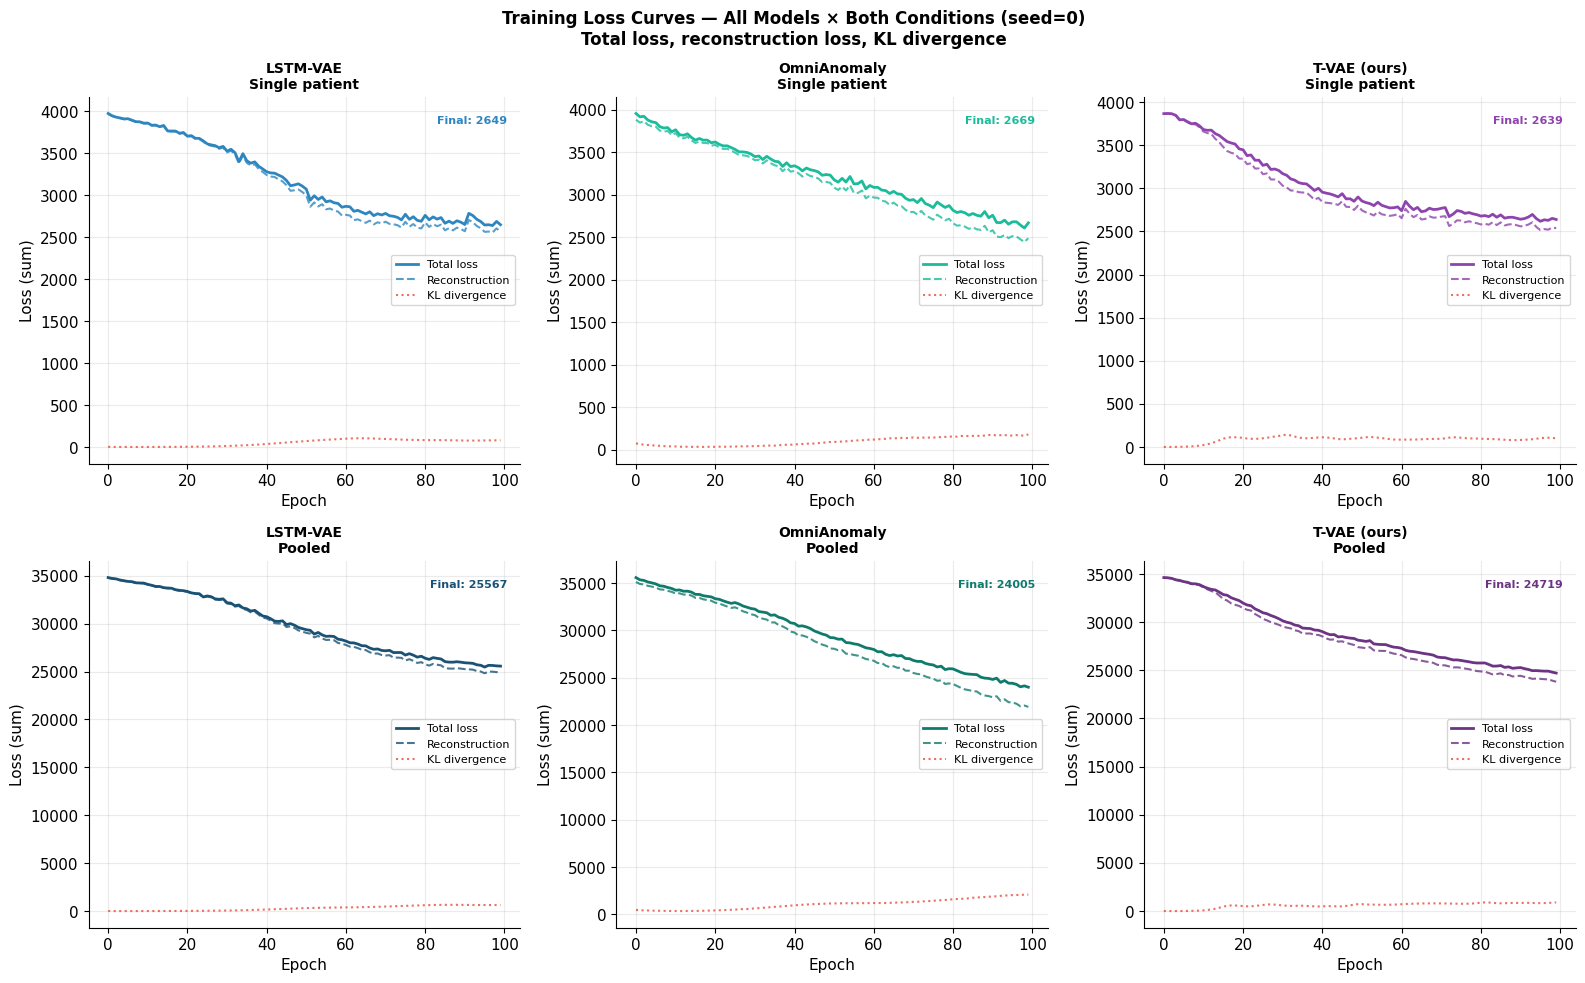

Saved fig3_training_curves.pdf


In [26]:
# ── FIGURE 3: TRAINING LOSS CURVES ────────────────────────────────────────────
print("Training seed=0 models for loss curve figure...")
histories = {}
for condition_name, cdata, suffix in [
    (SINGLE_LABEL, X_train_normal_c55f8, 's'),
    (POOLED_LABEL, X_train_pooled,        'p'),
]:
    for model_name, ModelClass in model_classes.items():
        key = f"{model_name}_{suffix}"
        print(f"  {key}...")
        _, hist = train_model(ModelClass, cdata, n_features=22,
                               hidden_dim=32, latent_dim=12,
                               n_epochs=100, lr=1e-3, seed=0, verbose=False)
        histories[key] = hist

print("Done.")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    'Training Loss Curves — All Models × Both Conditions (seed=0)\n'
    'Total loss, reconstruction loss, KL divergence',
    fontsize=12, fontweight='bold'
)

plot_order = [
    ('LSTM-VAE_s',    'LSTM-VAE\nSingle patient',     0, 0, '#2E86C1'),
    ('OmniAnomaly_s', 'OmniAnomaly\nSingle patient',  0, 1, '#1ABC9C'),
    ('T-VAE_s',       'T-VAE (ours)\nSingle patient', 0, 2, '#8E44AD'),
    ('LSTM-VAE_p',    'LSTM-VAE\nPooled',              1, 0, '#1A5276'),
    ('OmniAnomaly_p', 'OmniAnomaly\nPooled',           1, 1, '#0F7B6C'),
    ('T-VAE_p',       'T-VAE (ours)\nPooled',          1, 2, '#6C3483'),
]

for key, title, row, col, color in plot_order:
    ax   = axes[row][col]
    hist = histories[key]
    ax.plot(hist['epoch'], hist['total'], color=color,     lw=2.0,
            label='Total loss')
    ax.plot(hist['epoch'], hist['recon'], color=color,     lw=1.5,
            ls='--', alpha=0.8, label='Reconstruction')
    ax.plot(hist['epoch'], hist['kl'],    color='#E74C3C', lw=1.5,
            ls=':', alpha=0.8, label='KL divergence')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (sum)')
    ax.legend(fontsize=8); ax.grid(alpha=0.25)
    ax.text(0.97, 0.95, f"Final: {hist['total'][-1]:.0f}",
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGPATH / 'fig3_training_curves.pdf', bbox_inches='tight', dpi=300)
plt.savefig(FIGPATH / 'fig3_training_curves.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved fig3_training_curves.pdf")

Getting seed=0 scores for distribution figure...
  LSTM-VAE_s: AUROC=0.455
  OmniAnomaly_s: AUROC=0.576
  T-VAE_s: AUROC=0.576
  LSTM-VAE_p: AUROC=0.587
  OmniAnomaly_p: AUROC=0.675
  T-VAE_p: AUROC=0.600


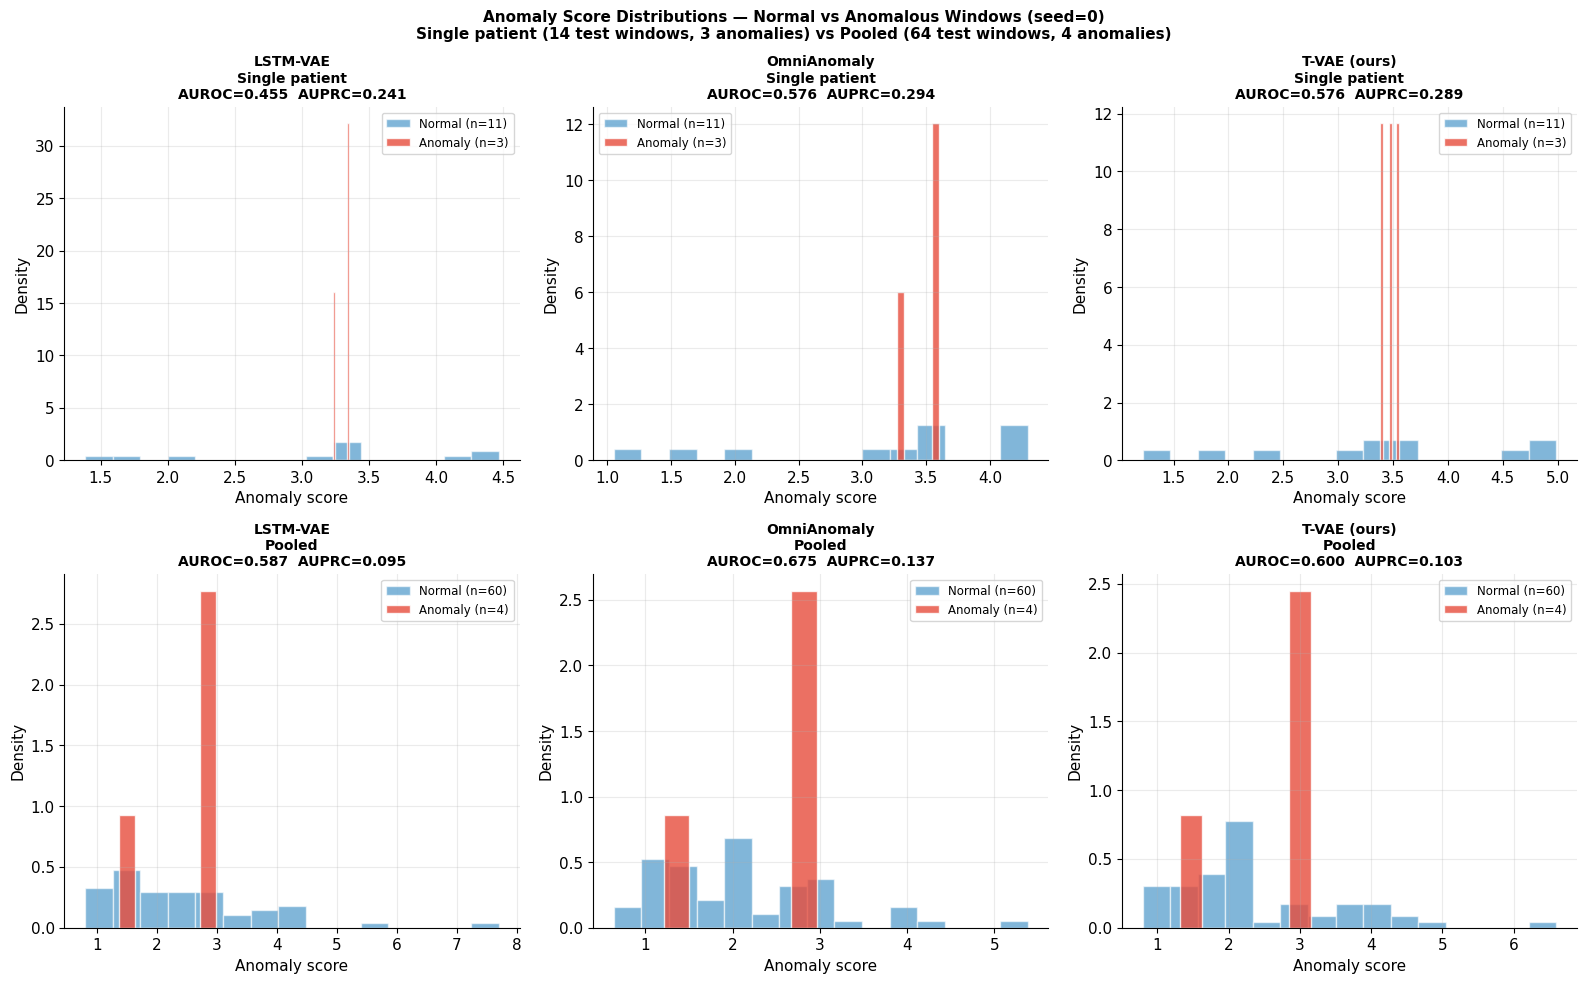

Saved fig4_score_distributions.pdf


In [27]:
# ── FIGURE 4: ANOMALY SCORE DISTRIBUTIONS ────────────────────────────────────
print("Getting seed=0 scores for distribution figure...")
score_results = {}
for condition_name, X_train_c, cdata, suffix in [
    ('Single patient', X_train_normal_c55f8, (X_test_c55f8, y_test_c55f8), 's'),
    ('Pooled',         X_train_pooled,       (X_test_pooled, y_test_pooled), 'p'),
]:
    X_test_c, y_test_c = cdata
    for model_name, ModelClass in model_classes.items():
        key = f"{model_name}_{suffix}"
        m, _ = train_model(ModelClass,
                            X_train_normal_c55f8 if suffix=='s' else X_train_pooled,
                            n_features=22, hidden_dim=32, latent_dim=12,
                            n_epochs=100, lr=1e-3, seed=0, verbose=False)
        score_results[key] = evaluate_model(
            m,
            X_test_c55f8 if suffix=='s' else X_test_pooled,
            y_test_c55f8 if suffix=='s' else y_test_pooled
        )
        print(f"  {key}: AUROC={score_results[key]['auroc']:.3f}")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    'Anomaly Score Distributions — Normal vs Anomalous Windows (seed=0)\n'
    f'Single patient ({len(X_test_c55f8)} test windows, '
    f'{int(y_test_c55f8.sum())} anomalies) vs '
    f'Pooled ({len(X_test_pooled)} test windows, '
    f'{int(y_test_pooled.sum())} anomalies)',
    fontsize=11, fontweight='bold'
)

for key, title, row, col in [
    ('LSTM-VAE_s',    'LSTM-VAE\nSingle patient',     0, 0),
    ('OmniAnomaly_s', 'OmniAnomaly\nSingle patient',  0, 1),
    ('T-VAE_s',       'T-VAE (ours)\nSingle patient', 0, 2),
    ('LSTM-VAE_p',    'LSTM-VAE\nPooled',              1, 0),
    ('OmniAnomaly_p', 'OmniAnomaly\nPooled',           1, 1),
    ('T-VAE_p',       'T-VAE (ours)\nPooled',          1, 2),
]:
    ax      = axes[row][col]
    res     = score_results[key]
    scores  = res['scores']
    labels  = res['labels']
    normal  = scores[labels == 0]
    anomaly = scores[labels == 1]

    ax.hist(normal,  bins=15, alpha=0.6, color='#2E86C1', density=True,
            edgecolor='white', label=f'Normal (n={len(normal)})')
    ax.hist(anomaly, bins=6,  alpha=0.8, color='#E74C3C', density=True,
            edgecolor='white', label=f'Anomaly (n={len(anomaly)})')
    ax.set_title(
        f'{title}\nAUROC={res["auroc"]:.3f}  AUPRC={res["auprc"]:.3f}',
        fontsize=10, fontweight='bold'
    )
    ax.set_xlabel('Anomaly score'); ax.set_ylabel('Density')
    ax.legend(fontsize=8.5); ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(FIGPATH / 'fig4_score_distributions.pdf', bbox_inches='tight', dpi=300)
plt.savefig(FIGPATH / 'fig4_score_distributions.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved fig4_score_distributions.pdf")

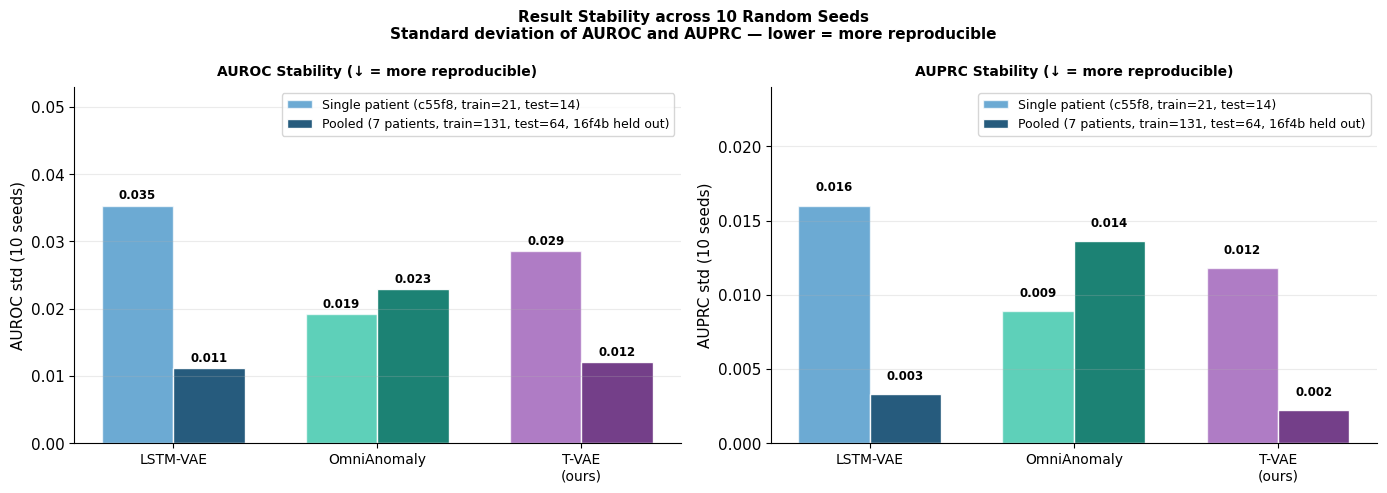

Saved fig5_seed_stability.pdf


In [28]:
# ── FIGURE 5: SEED STABILITY ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Result Stability across 10 Random Seeds\n'
    'Standard deviation of AUROC and AUPRC — lower = more reproducible',
    fontsize=11, fontweight='bold'
)

model_labels = ['LSTM-VAE', 'OmniAnomaly', 'T-VAE\n(ours)']
x5  = np.arange(len(model_labels))
w5  = 0.35
cs  = ['#2E86C1', '#1ABC9C', '#8E44AD']
cp  = ['#1A5276', '#0F7B6C', '#6C3483']

auroc_s_std = get_vals('Single patient', 'AUROC std')
auroc_p_std = get_vals('Pooled',         'AUROC std')
auprc_s_std = get_vals('Single patient', 'AUPRC std')
auprc_p_std = get_vals('Pooled',         'AUPRC std')

for ax, s_std, p_std, ylabel, title in zip(
    axes,
    [auroc_s_std, auprc_s_std],
    [auroc_p_std, auprc_p_std],
    ['AUROC std (10 seeds)', 'AUPRC std (10 seeds)'],
    ['AUROC Stability (↓ = more reproducible)',
     'AUPRC Stability (↓ = more reproducible)']
):
    b1 = ax.bar(x5 - w5/2, s_std, w5, color=cs, alpha=0.7,
                edgecolor='white',
                label=SINGLE_LABEL)
    b2 = ax.bar(x5 + w5/2, p_std, w5, color=cp, alpha=0.95,
                edgecolor='white',
                label=POOLED_LABEL)
    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{bar.get_height():.3f}',
                ha='center', fontsize=8.5, fontweight='bold')
    ax.set_xticks(x5); ax.set_xticklabels(model_labels, fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=8)
    ax.legend(fontsize=9); ax.grid(alpha=0.25, axis='y')
    ax.set_ylim(0, max(max(s_std), max(p_std)) * 1.5)

plt.tight_layout()
plt.savefig(FIGPATH / 'fig5_seed_stability.pdf', bbox_inches='tight', dpi=300)
plt.savefig(FIGPATH / 'fig5_seed_stability.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved fig5_seed_stability.pdf")

In [29]:
# ── 9. CONFORMAL PREDICTION (patient-level fit/calibration split) ───────────
print("="*60)
print("CONFORMAL PREDICTION - T-VAE Pooled (seed=0)")
print("="*60)

# Patient-LEVEL split instead of within-patient window splitting + purge gap.
# Windows from DIFFERENT patients never share raw days, so holding out
# entire patients for calibration guarantees zero fit/calibration overlap
# with no purge gap needed. This also avoids the earlier failure mode: a
# per-patient window-level split + purge gap requires each patient's
# normal-window block to be large enough to hold both a purge gap AND a
# calibration slice, which broke down here because every patient's block
# was too small under the leakage-safe pipeline (all blocks <= 6 windows).
import random
rng = random.Random(0)
patient_order = list(range(len(patient_normal_blocks)))
rng.shuffle(patient_order)

n_cal_patients  = max(1, int(len(patient_order) * 0.20))
cal_patient_idx = set(patient_order[:n_cal_patients])
fit_patient_idx = set(patient_order[n_cal_patients:])

fit_blocks = [patient_normal_blocks[i] for i in fit_patient_idx]
cal_blocks = [patient_normal_blocks[i] for i in cal_patient_idx]

block_report = [
    {'patient_index': i, 'block_size': len(patient_normal_blocks[i]),
     'role': 'calibration' if i in cal_patient_idx else 'fit'}
    for i in range(len(patient_normal_blocks))
]
print("Per-patient role assignment (patient-level fit/calibration split):")
print(pd.DataFrame(block_report).to_string(index=False))

if len(fit_blocks) == 0:
    raise ValueError(
        "No patients assigned to fit — check patient_normal_blocks upstream "
        "in Section 5.")
if len(cal_blocks) == 0:
    raise ValueError(
        "No patients assigned to calibration — increase n_cal_patients or "
        "check patient_normal_blocks upstream in Section 5.")

X_fit = torch.cat(fit_blocks, dim=0)
X_cal = torch.cat(cal_blocks, dim=0)

print(f"\nFit windows:         {X_fit.shape}  ({len(fit_patient_idx)} patients)")
print(f"Calibration windows: {X_cal.shape}  ({len(cal_patient_idx)} patients)")

# Train T-VAE on fit set only
print("\nTraining T-VAE on fit set...")
model_cp, _ = train_model(TVAE, X_fit, n_features=22, hidden_dim=32,
                            latent_dim=12, n_epochs=100, lr=1e-3,
                            seed=0, verbose=True)

# Deterministic scores (model.eval() -> z = mu inside get_anomaly_scores)
cal_scores  = get_anomaly_scores(model_cp, X_cal)
test_scores = get_anomaly_scores(model_cp, X_test_pooled)

print(f"\nCalibration scores - mean: {cal_scores.mean():.3f}  "
      f"std: {cal_scores.std():.3f}")

# Compute conformal thresholds + explicit nominal-vs-observed coverage
coverage_levels = [0.80, 0.85, 0.90, 0.95]
thresholds = {}

print(f"\n{'Nominal':>10s}  {'Threshold':>10s}  {'Observed cal':>13s}")
print("-"*38)
print("NOTE: 'Observed cal' is the empirical coverage measured ON THE "
      "CALIBRATION SET itself (fraction of calibration scores at/below "
      "threshold). This is NOT an independent held-out verification of the "
      "nominal level - report these numbers as an uncertainty-threshold "
      "analysis, not a formal distribution-free coverage guarantee, given "
      "the small calibration set.")
for coverage in coverage_levels:
    alpha          = 1 - coverage
    n_cal_size     = len(cal_scores)
    q_level        = min(np.ceil((n_cal_size+1)*(1-alpha))/n_cal_size, 1.0)
    threshold      = np.quantile(cal_scores, q_level)
    thresholds[coverage] = threshold
    observed_cal_coverage = (cal_scores <= threshold).mean()
    print(f"{coverage:>10.0%}  {threshold:>10.4f}  {observed_cal_coverage:>12.1%}")

# Evaluate on test set
y_test_np = y_test_pooled.numpy()
auprc_cp  = average_precision_score(y_test_np, test_scores)
auroc_cp  = roc_auc_score(y_test_np, test_scores)

print(f"\nRaw score metrics - AUPRC: {auprc_cp:.4f}  AUROC: {auroc_cp:.4f}")
print(f"\nAlert-level evaluation:")
print(f"{'Nominal':>10s}  {'Observed cal':>13s}  {'Threshold':>10s}  {'Alerts':>8s}  "
      f"{'TP':>5s}  {'FP':>5s}  {'FN':>5s}  "
      f"{'Precision':>10s}  {'Recall':>8s}")
print("-"*85)

cp_results = []
for coverage, threshold in thresholds.items():
    observed_cal_coverage = (cal_scores <= threshold).mean()
    y_pred    = (test_scores > threshold).astype(int)
    tp = int(((y_pred==1) & (y_test_np==1)).sum())
    fp = int(((y_pred==1) & (y_test_np==0)).sum())
    fn = int(((y_pred==0) & (y_test_np==1)).sum())
    precision = tp/(tp+fp) if (tp+fp)>0 else 0.0
    recall    = tp/(tp+fn) if (tp+fn)>0 else 0.0
    print(f"{coverage:>10.0%}  {observed_cal_coverage:>12.1%}  {threshold:>10.4f}  "
          f"{y_pred.sum():>8d}  {tp:>5d}  {fp:>5d}  {fn:>5d}  "
          f"{precision:>10.4f}  {recall:>8.4f}")
    cp_results.append({'Coverage_nominal': coverage,
                        'Coverage_observed_calibration': round(observed_cal_coverage, 4),
                        'Threshold': round(threshold,4),
                        'AUPRC': round(auprc_cp,4), 'AUROC': round(auroc_cp,4),
                        'Alerts': int(y_pred.sum()), 'TP': tp, 'FP': fp,
                        'FN': fn, 'Precision': round(precision,4),
                        'Recall': round(recall,4)})

cp_df = pd.DataFrame(cp_results)
cp_df.to_csv(RESPATH / 'table_conformal_prediction.csv', index=False)
print("\nSaved table_conformal_prediction.csv")

CONFORMAL PREDICTION - T-VAE Pooled (seed=0)
Per-patient role assignment (patient-level fit/calibration split):
 patient_index  block_size        role
             0          13         fit
             1          27         fit
             2          24         fit
             3           4         fit
             4          21 calibration
             5          15         fit
             6          27         fit

Fit windows:         torch.Size([110, 7, 22])  (6 patients)
Calibration windows: torch.Size([21, 7, 22])  (1 patients)

Training T-VAE on fit set...
  Epoch   0 | total: 30786.43 | recon: 30779.36 | kl: 7.08
  Epoch  10 | total: 29737.79 | recon: 29652.69 | kl: 85.10
  Epoch  20 | total: 28040.54 | recon: 27583.00 | kl: 457.54
  Epoch  30 | total: 26468.75 | recon: 25891.40 | kl: 577.35
  Epoch  40 | total: 24999.39 | recon: 24422.47 | kl: 576.91
  Epoch  50 | total: 24007.40 | recon: 23340.19 | kl: 667.21
  Epoch  60 | total: 23215.03 | recon: 22467.23 | kl: 747.80
  

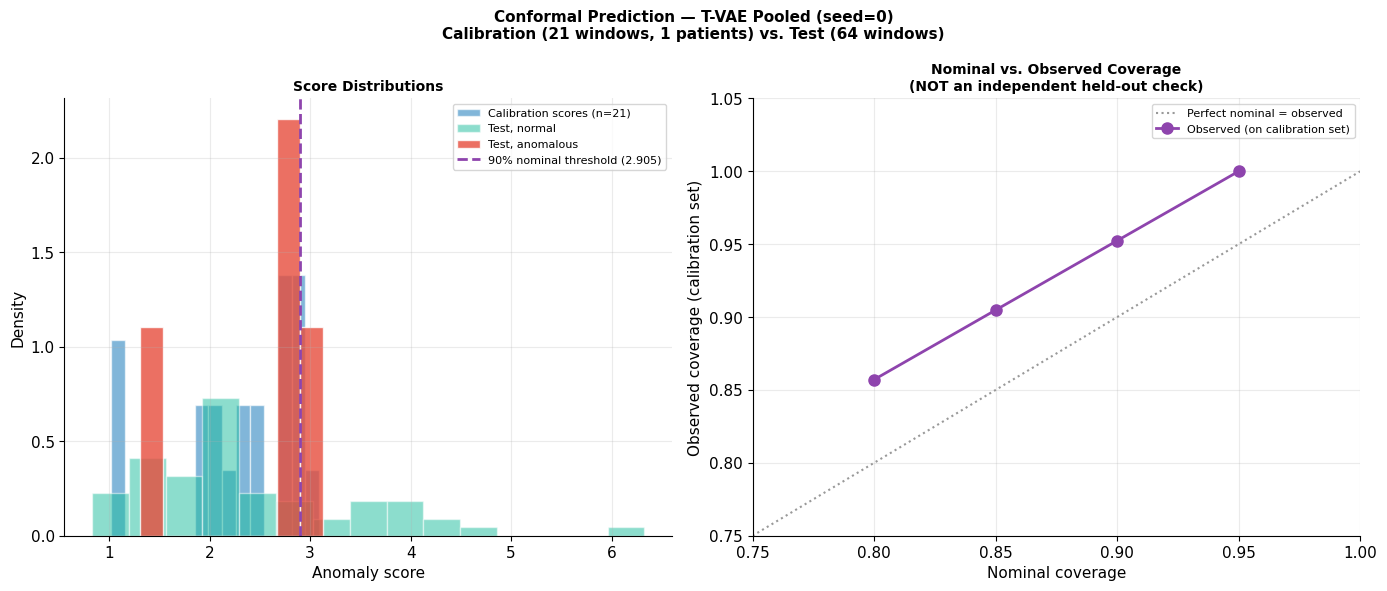

Saved fig6_conformal_prediction.pdf


In [30]:
# ── FIGURE 6: CONFORMAL PREDICTION ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Conformal Prediction — T-VAE Pooled (seed=0)\n'
    f'Calibration ({len(cal_scores)} windows, {len(cal_patient_idx)} patients) vs. '
    f'Test ({len(test_scores)} windows)',
    fontsize=11, fontweight='bold'
)

# Panel 1: score distributions with the 90% threshold marked
ax = axes[0]
ax.hist(cal_scores, bins=15, alpha=0.6, color='#2E86C1', density=True,
        edgecolor='white', label=f'Calibration scores (n={len(cal_scores)})')
ax.hist(test_scores[y_test_np == 0], bins=15, alpha=0.5, color='#1ABC9C',
        density=True, edgecolor='white', label='Test, normal')
ax.hist(test_scores[y_test_np == 1], bins=8, alpha=0.8, color='#E74C3C',
        density=True, edgecolor='white', label='Test, anomalous')
threshold_90 = thresholds[0.90]
ax.axvline(threshold_90, color='#8E44AD', lw=2, ls='--',
           label=f'90% nominal threshold ({threshold_90:.3f})')
ax.set_xlabel('Anomaly score'); ax.set_ylabel('Density')
ax.set_title('Score Distributions', fontsize=10, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.25)

# Panel 2: nominal vs. observed calibration coverage across levels
ax = axes[1]
noms = cp_df['Coverage_nominal'].values
obs  = cp_df['Coverage_observed_calibration'].values
ax.plot([0.75, 1.0], [0.75, 1.0], color='#999', ls=':', lw=1.5,
        label='Perfect nominal = observed')
ax.plot(noms, obs, marker='o', color='#8E44AD', lw=2, ms=8,
        label='Observed (on calibration set)')
ax.set_xlabel('Nominal coverage'); ax.set_ylabel('Observed coverage (calibration set)')
ax.set_title('Nominal vs. Observed Coverage\n(NOT an independent held-out check)',
             fontsize=10, fontweight='bold')
ax.set_xlim(0.75, 1.0); ax.set_ylim(0.75, 1.05)
ax.legend(fontsize=8); ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(FIGPATH / 'fig6_conformal_prediction.pdf', bbox_inches='tight', dpi=300)
plt.savefig(FIGPATH / 'fig6_conformal_prediction.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved fig6_conformal_prediction.pdf")

In [31]:
# ── 10. QUALITATIVE CASE STUDY - Patient 16f4b (EXPLORATORY, RETROSPECTIVE) ──
# NOTE: 16f4b was excluded from pooled training (see Section 5), so model_cp
# has never seen this patient's data - this is a genuine held-out illustration,
# not an in-sample check. It remains an EXPLORATORY, RETROSPECTIVE example,
# not a validated prospective early-warning result: the threshold and scoring
# window were not fixed ahead of time relative to this specific episode.

pid_16f4b = [p for p in COMPLETE_PATIENTS if str(p).startswith('16f4b')][0]

daily_16   = build_daily_table(pid_16f4b, tihm)
imputed_16 = impute_missing(daily_16, calibration_days=14)
normed_16, stats_16, _ = normalise_patient(imputed_16, calibration_days=14)
feature_cols_16 = [c for c in normed_16.columns if c not in ['anomaly', 'patient_id']]

# Use ALL of 16f4b's post-calibration days as one continuous segment for
# visualisation purposes only (this patient contributes no training data)
post_cal_16 = normed_16.iloc[14:].reset_index()
X_16, y_16_endpoint, y_16_any, dates_16 = create_windows_from_segment(
    post_cal_16, feature_cols_16, window_size=7, step=1)
dates_16_pd = pd.to_datetime(dates_16)

# Anomaly scores from the held-out conformal model (deterministic: model.eval()
# inside get_anomaly_scores now fixes z = mu, so these scores are reproducible)
scores_16 = get_anomaly_scores(model_cp, X_16)

# Express scores as a percentile against the CALIBRATION distribution (fixed,
# independent of this patient's own future scores) rather than min-max
# normalising against this patient's own full timeline, which would leak
# future information into the visualisation.
scores_16_norm = np.array([(cal_scores <= s).mean() for s in scores_16])

# Clinician labels for this patient
labels_16 = tihm['labels'][tihm['labels'].patient_id == pid_16f4b].copy()
labels_16['day'] = labels_16.date.dt.normalize()
agitation_dates = labels_16[labels_16.type == 'Agitation']['day']

early_warning = pd.Timestamp('2019-05-06')
ew_idx = list(dates_16_pd).index(early_warning)

# Gap to the nearest clinician-labelled event, computed dynamically rather
# than hardcoded, since the exact gap should be read from the data each run
gap_days = int((agitation_dates.min() - early_warning).days) if len(agitation_dates) else None

# Raw sleep awake data
raw_sleep_16 = tihm['sleep'][tihm['sleep'].patient_id == pid_16f4b].copy()
raw_sleep_16['day'] = raw_sleep_16.date.dt.normalize()
awake_daily = raw_sleep_16[raw_sleep_16.state == 'AWAKE'].groupby('day').size()
awake_full  = awake_daily.reindex(
    pd.date_range(daily_16.index.min(), daily_16.index.max(), freq='D'),
    fill_value=0
)

print(f"Patient 16f4b - {len(daily_16)} days, {len(X_16)} windows (HELD OUT of pooled training)")
print(f"May 6th anomaly score (percentile vs. calibration distribution): {scores_16_norm[ew_idx]:.3f}")
print(f"Agitation event dates: {list(agitation_dates.dt.date)}")
if gap_days is not None:
    print(f"Gap from flagged day to nearest labelled event: {gap_days} day(s)")
print("Framing: exploratory, retrospective illustration - not a validated "
      "prospective early-warning claim.")


Patient 16f4b - 91 days, 71 windows (HELD OUT of pooled training)
May 6th anomaly score (percentile vs. calibration distribution): 1.000
Agitation event dates: [datetime.date(2019, 4, 11), datetime.date(2019, 4, 14), datetime.date(2019, 4, 15), datetime.date(2019, 4, 16), datetime.date(2019, 4, 21), datetime.date(2019, 4, 22), datetime.date(2019, 4, 26), datetime.date(2019, 5, 10), datetime.date(2019, 5, 11), datetime.date(2019, 5, 14), datetime.date(2019, 5, 19)]
Gap from flagged day to nearest labelled event: -25 day(s)
Framing: exploratory, retrospective illustration - not a validated prospective early-warning claim.


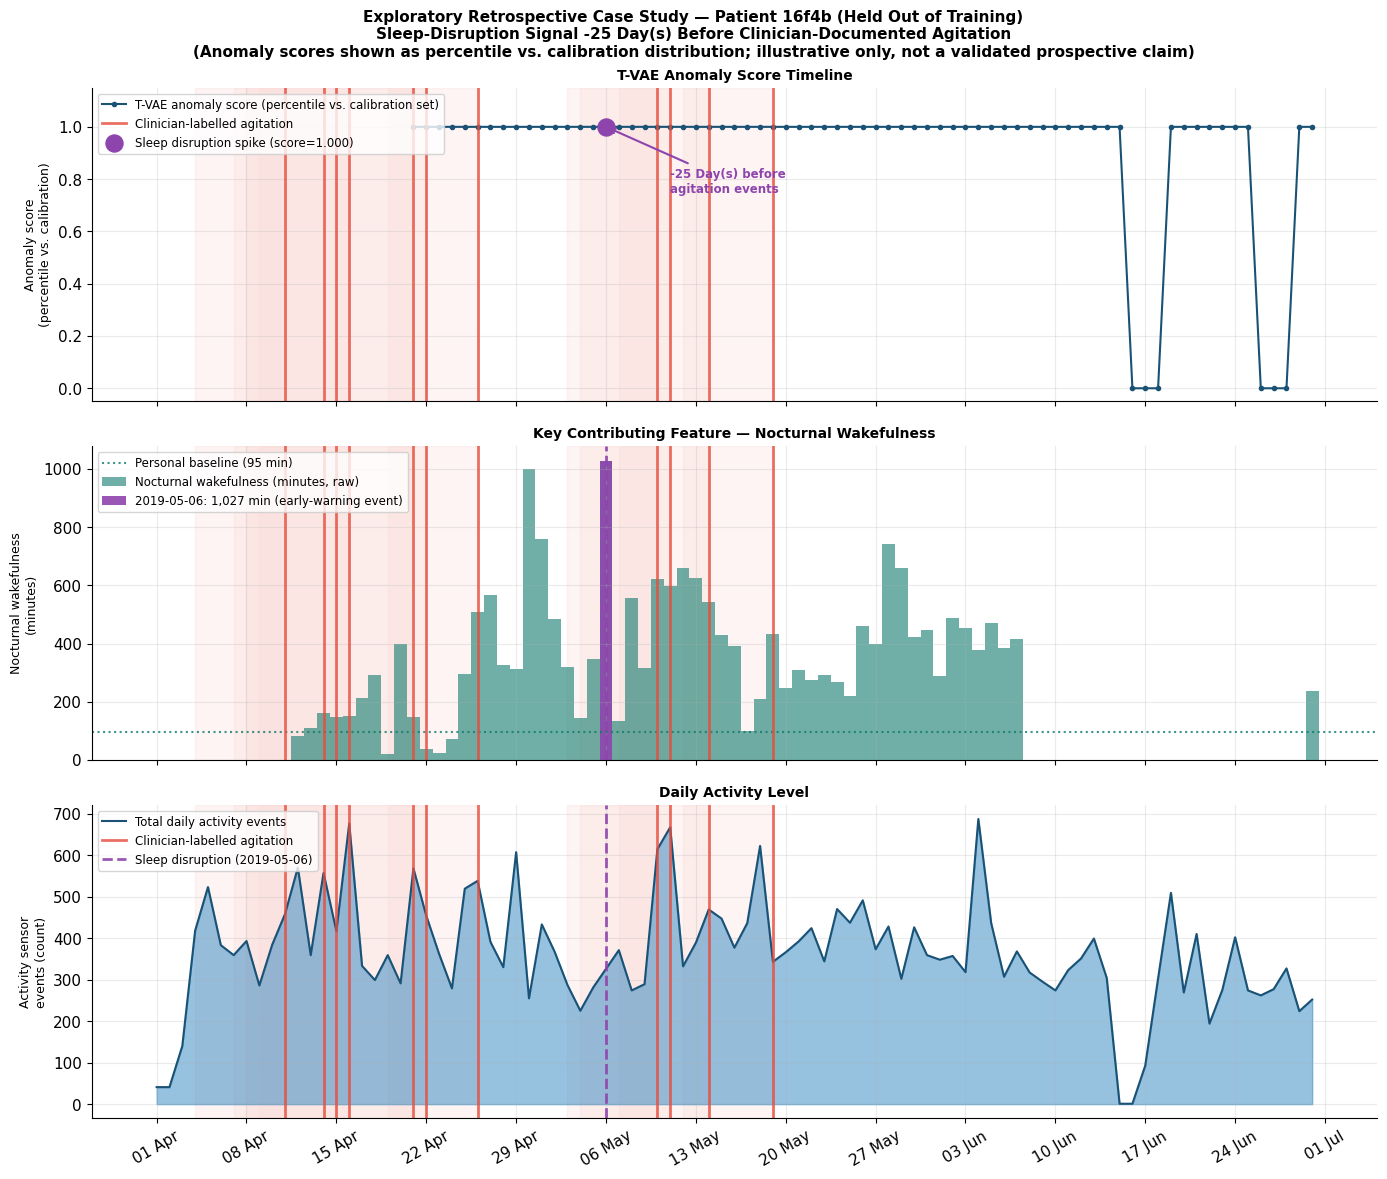

Saved fig7_case_study_16f4b.pdf


In [32]:
# ── FIGURE 7: QUALITATIVE CASE STUDY ─────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
gap_label = f"{gap_days} Day(s)" if gap_days is not None else "an Unspecified Interval"
fig.suptitle(
    'Exploratory Retrospective Case Study — Patient 16f4b (Held Out of Training)\n'
    f'Sleep-Disruption Signal {gap_label} Before Clinician-Documented Agitation\n'
    '(Anomaly scores shown as percentile vs. calibration distribution; '
    'illustrative only, not a validated prospective claim)',
    fontsize=11, fontweight='bold'
)

# Panel 1: Anomaly score
ax = axes[0]
ax.plot(dates_16_pd, scores_16_norm, color='#1A5276', lw=1.5,
        marker='o', ms=3, label='T-VAE anomaly score (percentile vs. calibration set)')
for ag_date in agitation_dates:
    ax.axvspan(ag_date - pd.Timedelta(days=7), ag_date,
               color='#FADBD8', alpha=0.3, zorder=0)
    ax.axvline(ag_date, color='#E74C3C', lw=2, alpha=0.8,
               label='Clinician-labelled agitation' \
               if ag_date == agitation_dates.iloc[0] else '')
ax.scatter([early_warning], [scores_16_norm[ew_idx]],
           color='#8E44AD', s=150, zorder=10,
           label=f'Sleep disruption spike (score={scores_16_norm[ew_idx]:.3f})')
ax.annotate(
    f'{gap_label} before\nagitation events' if gap_days is not None else 'flagged day',
    xy=(early_warning, scores_16_norm[ew_idx]),
    xytext=(early_warning + pd.Timedelta(days=5), 0.75),
    fontsize=8.5, color='#8E44AD', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#8E44AD', lw=1.5)
)
ax.set_ylabel('Anomaly score\n(percentile vs. calibration)', fontsize=9)
ax.set_ylim(-0.05, 1.15)
ax.set_title('T-VAE Anomaly Score Timeline', fontsize=10, fontweight='bold')
ax.legend(fontsize=8.5, loc='upper left'); ax.grid(alpha=0.25)

# Panel 2: Raw sleep awake
ax = axes[1]
ax.bar(awake_full.index, awake_full.values, color='#0F7B6C',
       alpha=0.6, width=1, label='Nocturnal wakefulness (minutes, raw)')
ax.bar([pd.Timestamp('2019-05-06')], [1027], color='#8E44AD',
       alpha=0.9, width=1,
       label='2019-05-06: 1,027 min (early-warning event)')
ax.axhline(stats_16.loc['sleep_awake', 'mean'], color='#0F7B6C',
           ls=':', lw=1.5, alpha=0.8,
           label=f"Personal baseline ({stats_16.loc['sleep_awake','mean']:.0f} min)")
for ag_date in agitation_dates:
    ax.axvspan(ag_date - pd.Timedelta(days=7), ag_date,
               color='#FADBD8', alpha=0.3, zorder=0)
    ax.axvline(ag_date, color='#E74C3C', lw=2, alpha=0.8)
ax.axvline(early_warning, color='#8E44AD', lw=2, ls='--', alpha=0.9)
ax.set_ylabel('Nocturnal wakefulness\n(minutes)', fontsize=9)
ax.set_title('Key Contributing Feature — Nocturnal Wakefulness',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8.5, loc='upper left'); ax.grid(alpha=0.25)

# Panel 3: Activity
ax = axes[2]
act_cols  = [c for c in imputed_16.columns if c.startswith('act_')]
total_act = imputed_16[act_cols].sum(axis=1)
ax.fill_between(total_act.index, total_act.values,
                color='#2E86C1', alpha=0.5)
ax.plot(total_act.index, total_act.values, color='#1A5276', lw=1.5,
        label='Total daily activity events')
for ag_date in agitation_dates:
    ax.axvspan(ag_date - pd.Timedelta(days=7), ag_date,
               color='#FADBD8', alpha=0.3, zorder=0)
    ax.axvline(ag_date, color='#E74C3C', lw=2, alpha=0.8,
               label='Clinician-labelled agitation' \
               if ag_date == agitation_dates.iloc[0] else '')
ax.axvline(early_warning, color='#8E44AD', lw=2, ls='--', alpha=0.9,
           label='Sleep disruption (2019-05-06)')
ax.set_ylabel('Activity sensor\nevents (count)', fontsize=9)
ax.set_title('Daily Activity Level', fontsize=10, fontweight='bold')
ax.legend(fontsize=8.5, loc='upper left'); ax.grid(alpha=0.25)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig(FIGPATH / 'fig7_case_study_16f4b.pdf', bbox_inches='tight', dpi=300)
plt.savefig(FIGPATH / 'fig7_case_study_16f4b.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved fig7_case_study_16f4b.pdf")

In [33]:
# ── 11. SINGLE-SPLIT EVALUATION SUMMARY (SUPERSEDED — see rolling-origin
#        benchmark at the end of this notebook for the primary result) ─────
print('NOTE: this single 75/25 split evaluation is retained for methodological\n'
      'transparency. It is SUPERSEDED as the primary result by the two-fold\n'
      'rolling-origin benchmark (final section of this notebook), which uses\n'
      'a larger, less patient-concentrated test signal.\n')
print("="*65)
print("FINAL RESULTS SUMMARY")
print("="*65)

print("\nTable 1 - Canonical 10-Seed Evaluation + Non-Neural Baselines:")
print(results_df[['Model', 'Condition', 'AUROC median', 'AUROC std',
                   'AUPRC median', 'AUPRC std',
                   'Chance AUPRC']].to_string(index=False))

print(f"\nTable 2 - Conformal Prediction (T-VAE, pooled, seed=0):")
print("(Coverage_observed_calibration is measured ON the calibration set "
      "itself, not an independent held-out verification - see Section 9.)")
print(cp_df[['Coverage_nominal', 'Coverage_observed_calibration', 'Threshold',
             'Alerts', 'TP', 'FP', 'FN', 'Precision', 'Recall']].to_string(index=False))

print(f"\nTable 3 - Per-Patient Pooled Test Breakdown:")
print(per_patient_df.to_string(index=False))

# ── Everything below is computed from the tables/arrays above, never
# hardcoded, so it can't drift out of sync. ──────────────────────────────────
pooled_mask = results_df['Condition'].str.contains('Pooled')
pooled = results_df[pooled_mask].set_index('Model')
single = results_df[results_df['Condition'].str.startswith('Single')].set_index('Model')

single_below_chance = (single.loc[['LSTM-VAE','OmniAnomaly','T-VAE'], 'AUROC median'] < 0.5).all()
cp_90 = cp_df[cp_df['Coverage_nominal'] == 0.900].iloc[0]

# Neural-model seed-level comparison (Section 7.1)
_, p_omni_tvae = scipy_stats.wilcoxon(model_aurocs['OmniAnomaly'], model_aurocs['T-VAE'])
_, p_tvae_lstm = scipy_stats.wilcoxon(model_aurocs['T-VAE'], model_aurocs['LSTM-VAE'])
_, p_omni_lstm = scipy_stats.wilcoxon(model_aurocs['OmniAnomaly'], model_aurocs['LSTM-VAE'])

# Per-patient concentration (Step 5)
n_patients_total = len(per_patient_df)
n_patients_with_events = int((per_patient_df['Positive endpoint alerts'] > 0).sum())
total_pooled_alerts = int(per_patient_df['Positive endpoint alerts'].sum())

print(f"\nKey findings:")
print(f"  1. Single-patient (n={len(X_test_c55f8)+len(X_train_normal_c55f8)}): "
      f"{'all neural models below chance AUROC' if single_below_chance else 'neural models split around chance AUROC (' + ', '.join(f'{m}={v:.3f}' for m, v in single.loc[['LSTM-VAE','OmniAnomaly','T-VAE'], 'AUROC median'].items()) + ')'}")
print(f"  2. Pooled ranking by AUROC median: "
      + ', '.join(f"{m}={v:.3f}" for m, v in pooled['AUROC median'].sort_values(ascending=False).items()))
print(f"  3. Neural-model seed-level comparison (10 seeds, Wilcoxon): "
      f"OmniAnomaly > T-VAE p={p_omni_tvae:.4f} (significant); "
      f"OmniAnomaly > LSTM-VAE p={p_omni_lstm:.4f} (significant); "
      f"T-VAE vs LSTM-VAE p={p_tvae_lstm:.4f} (NOT significant)")
print(f"  4. PCA (k={pca_final['n_components']}, training-only, documented in "
      f"Step 1) vs neural models (10 seeds each, Wilcoxon): "
      f"PCA beats OmniAnomaly every seed, p={p_omni:.4f}; "
      f"PCA beats T-VAE every seed, p={p_tvae:.4f}. "
      f"No neural model demonstrates an advantage over simple linear "
      f"reconstruction error on this cohort.")
print(f"  5. PCA pooled AUROC test-set bootstrap 95% CI: [{lo:.4f}, {hi:.4f}] "
      f"(n={n_valid} valid resamples) - this is EXTREMELY wide, meaning "
      f"finding #4's ranking, while consistent across training seeds, is "
      f"NOT robust to which test windows happen to be included.")
print(f"  6. CRITICAL LIMITATION: only {n_patients_with_events} of "
      f"{n_patients_total} pooled patients contribute any positive test "
      f"label at all ({total_pooled_alerts} total alerts, entirely from "
      f"patients 96adf and c55f8). Every pooled AUROC number above - for "
      f"every model - is effectively a 2-patient comparison, not a broad "
      f"cohort finding. See Table 3.")
print(f"  7. Conformal (nominal 90% coverage, uncertainty-threshold analysis, "
      f"not a formal guarantee, patient-level calibration split): "
      f"precision={cp_90['Precision']:.3f}, recall={cp_90['Recall']:.3f}")
print(f"  8. Patient {CASE_STUDY_PID} (held out of pooled training): "
      f"exploratory retrospective signal observed before clinician-labelled "
      f"agitation - not a validated prospective early-warning result")

print(f"\nCONCLUSION: Under the leakage-safe protocol, the proposed T-VAE "
      f"does NOT outperform simpler baselines - OmniAnomaly beats it on "
      f"pooled AUROC (p={p_omni_tvae:.4f}), and PCA reconstruction error "
      f"beats ALL neural models with high seed-level consistency "
      f"(p={p_omni:.4f}, p={p_tvae:.4f}). However, this entire pooled "
      f"comparison rests on only {total_pooled_alerts} positive labels "
      f"concentrated in {n_patients_with_events} of {n_patients_total} "
      f"patients, so absolute rankings should be treated as fragile and "
      f"cohort-size-limited rather than as strong evidence of a stable "
      f"model ordering. A larger, more diverse patient cohort is needed "
      f"to resolve this with confidence.")

# Save canonical tables
results_df.to_csv(RESPATH / 'table_canonical_10seed.csv', index=False)
per_patient_df.to_csv(RESPATH / 'table_per_patient_pooled_test.csv', index=False)

print(f"\nFigures saved:")
for f in sorted(os.listdir(FIGPATH)):
    fpath = FIGPATH / f
    if f.endswith('.pdf') and fpath.is_file():
        size = os.path.getsize(fpath)
        print(f"  {f:45s} {size:>10,} bytes")

print(f"\nResults saved:")
for f in sorted(os.listdir(RESPATH)):
    fpath = RESPATH / f
    if fpath.is_file() and not f.startswith('.'):
        size = os.path.getsize(fpath)
        print(f"  {f:45s} {size:>10,} bytes")

NOTE: this single 75/25 split evaluation is retained for methodological
transparency. It is SUPERSEDED as the primary result by the two-fold
rolling-origin benchmark (final section of this notebook), which uses
a larger, less patient-concentrated test signal.

FINAL RESULTS SUMMARY

Table 1 - Canonical 10-Seed Evaluation + Non-Neural Baselines:
          Model                                               Condition  AUROC median  AUROC std  AUPRC median  AUPRC std  Chance AUPRC
       LSTM-VAE               Single patient (c55f8, train=21, test=14)         0.485      0.035         0.250      0.016         0.214
    OmniAnomaly               Single patient (c55f8, train=21, test=14)         0.576      0.019         0.294      0.009         0.214
          T-VAE               Single patient (c55f8, train=21, test=14)         0.515      0.029         0.261      0.012         0.214
       LSTM-VAE Pooled (7 patients, train=131, test=64, 16f4b held out)         0.583      0.011         0.09

In [34]:
# ── EVENT-DISTRIBUTION AUDIT (all eligible patients, across time) ───────────
audit_rows = []
for pid in COMPLETE_PATIENTS:
    daily = build_daily_table(pid, tihm)
    train_daily, test_daily = split_daily_timeline(daily, calibration_days=14, test_ratio=0.25)
    cal_window = daily.iloc[:14]

    alert_dates = daily.index[daily['anomaly'] == 1]

    audit_rows.append({
        'Patient ID': str(pid)[:12],
        'Total usable days': len(daily),
        'Total verified alert days': int(daily['anomaly'].sum()),
        'Alerts in calibration period': int(cal_window['anomaly'].sum()),
        'Alerts in training period': int(train_daily['anomaly'].sum()) if 'anomaly' in train_daily else None,
        'Alerts in current test period': int(test_daily['anomaly'].sum()) if 'anomaly' in test_daily else None,
        'Earliest alert date': alert_dates.min().date() if len(alert_dates) else None,
        'Latest alert date': alert_dates.max().date() if len(alert_dates) else None,
    })

audit_df = pd.DataFrame(audit_rows)
print(audit_df.to_string(index=False))
audit_df.to_csv(RESPATH / 'event_distribution_audit.csv', index=False)
print("\nSaved event_distribution_audit.csv")

Patient ID  Total usable days  Total verified alert days  Alerts in calibration period  Alerts in training period  Alerts in current test period Earliest alert date Latest alert date
     16f4b                 91                         13                             3                         10                              0          2019-04-08        2019-05-19
     1fbe4                 68                          9                             3                          4                              2          2019-04-30        2019-06-21
     30a32                 66                         19                             6                         12                              1          2019-04-28        2019-06-26
     55cd4                 77                          2                             0                          2                              0          2019-05-05        2019-05-23
     93c14                 49                         14                             

In [35]:
# ── TWO-FOLD ROLLING-ORIGIN FEASIBILITY AUDIT ────────────────────────────────
# Defines the walk-forward 2-fold split used below, and checks -- BEFORE any
# model training -- whether each fold has enough clean training data and
# test-period alerts per patient to be usable. This audit is what justified
# moving to a two-fold design in the first place (see event-distribution
# audit above: the original single split recovered only 4 of 13 real
# alert-days; this design was built to test whether that could be improved).
def make_two_folds(daily, calibration_days=14):
    """Walk-forward 2-fold split of post-calibration days into 3 equal
    chunks (A, B, C): Fold 1 = train A / test B. Fold 2 = train A+B / test C
    (Fold 2 mirrors the original single-split protocol)."""
    post_cal = daily.iloc[calibration_days:]
    n = len(post_cal)
    third = n // 3
    A = post_cal.iloc[:third]
    B = post_cal.iloc[third:2*third]
    C = post_cal.iloc[2*third:]
    fold1 = {'train': A, 'test': B}
    fold2 = {'train': pd.concat([A, B]), 'test': C}
    return fold1, fold2

feasibility_rows = []
for pid in COMPLETE_PATIENTS:
    if str(pid).startswith(CASE_STUDY_PID):
        continue  # 16f4b stays held out, consistent with Section 5
    daily = build_daily_table(pid, tihm)
    imputed = impute_missing(daily, calibration_days=14)
    normed, stats, no_signal = normalise_patient(imputed, calibration_days=14)
    feature_cols = [c for c in normed.columns if c not in ['anomaly', 'patient_id']]
    fold1, fold2 = make_two_folds(normed, calibration_days=14)

    for fold_name, fold in [('Fold 1', fold1), ('Fold 2', fold2)]:
        train_seg = fold['train'].reset_index()
        test_seg  = fold['test'].reset_index()
        X_train_f, _, y_train_any_f, _ = create_windows_from_segment(
            train_seg, feature_cols, window_size=7, step=1)
        X_test_f, y_test_endpoint_f, _, _ = create_windows_from_segment(
            test_seg, feature_cols, window_size=7, step=1)
        clean_normal = int((y_train_any_f == 0).sum()) if len(y_train_any_f) else 0
        feasibility_rows.append({
            'Patient': str(pid)[:12], 'Fold': fold_name,
            'Train days': len(fold['train']), 'Test days': len(fold['test']),
            'Train windows (raw)': len(X_train_f),
            'Train windows (clean normal)': clean_normal,
            'Test windows': len(X_test_f),
            'Test alerts': int(y_test_endpoint_f.sum()) if len(y_test_endpoint_f) else 0,
            'VIABLE': clean_normal > 0 and len(X_test_f) > 0,
        })

feasibility_df = pd.DataFrame(feasibility_rows)
print(feasibility_df.to_string(index=False))
feasibility_df.to_csv(RESPATH / 'two_fold_feasibility_audit.csv', index=False)

print(f"\nSummary: Fold 1 viable patients: "
      f"{feasibility_df[(feasibility_df.Fold=='Fold 1') & feasibility_df.VIABLE].shape[0]} / "
      f"{feasibility_df[feasibility_df.Fold=='Fold 1'].shape[0]}")
print(f"Fold 2 viable patients: "
      f"{feasibility_df[(feasibility_df.Fold=='Fold 2') & feasibility_df.VIABLE].shape[0]} / "
      f"{feasibility_df[feasibility_df.Fold=='Fold 2'].shape[0]}")
print(f"Total test alerts, Fold 1: {feasibility_df[feasibility_df.Fold=='Fold 1']['Test alerts'].sum()}")
print(f"Total test alerts, Fold 2: {feasibility_df[feasibility_df.Fold=='Fold 2']['Test alerts'].sum()}")


Patient   Fold  Train days  Test days  Train windows (raw)  Train windows (clean normal)  Test windows  Test alerts  VIABLE
  1fbe4 Fold 1          18         18                   12                             2            12            1    True
  1fbe4 Fold 2          36         18                   30                            13            12            2    True
  30a32 Fold 1          17         17                   11                             0            11            3   False
  30a32 Fold 2          34         18                   28                             0            12            1   False
  55cd4 Fold 1          21         21                   15                             8            15            0    True
  55cd4 Fold 2          42         21                   36                            22            15            0    True
  93c14 Fold 1          11         11                    5                             0             5            1   False
  93c14 

In [36]:
# ── BUILD PER-FOLD POOLED DATASETS (PCA/OmniAnomaly/T-VAE eval targets) ─────
def build_fold_pool(fold_key, fold_data_by_patient):
    all_X_normal, all_X_test, all_y_test, all_ids = [], [], [], []
    for pid, (fold1, fold2) in fold_data_by_patient.items():
        fold = fold1 if fold_key == 'Fold 1' else fold2
        feature_cols = fold['feature_cols']
        X_train_f, _, y_train_any_f, _ = create_windows_from_segment(
            fold['train'].reset_index(), feature_cols, window_size=7, step=1)
        X_test_f, y_test_endpoint_f, _, _ = create_windows_from_segment(
            fold['test'].reset_index(), feature_cols, window_size=7, step=1)
        clean_mask = (y_train_any_f == 0) if len(y_train_any_f) else None
        if clean_mask is None or clean_mask.sum() == 0 or len(X_test_f) == 0:
            continue
        all_X_normal.append(X_train_f[clean_mask])
        all_X_test.append(X_test_f)
        all_y_test.append(y_test_endpoint_f)
        all_ids.append([pid] * len(X_test_f))
    X_train_pool = torch.cat(all_X_normal, dim=0)
    X_test_pool  = torch.cat(all_X_test, dim=0)
    y_test_pool  = torch.cat(all_y_test, dim=0)
    ids_pool     = [pid for block in all_ids for pid in block]
    return X_train_pool, X_test_pool, y_test_pool, ids_pool

fold_data_by_patient = {}
for pid in COMPLETE_PATIENTS:
    if str(pid).startswith(CASE_STUDY_PID):
        continue
    daily = build_daily_table(pid, tihm)
    imputed = impute_missing(daily, calibration_days=14)
    normed, stats, no_signal = normalise_patient(imputed, calibration_days=14)
    feature_cols = [c for c in normed.columns if c not in ['anomaly', 'patient_id']]
    fold1, fold2 = make_two_folds(normed, calibration_days=14)
    fold1['feature_cols'] = feature_cols
    fold2['feature_cols'] = feature_cols
    fold_data_by_patient[str(pid)[:12]] = (fold1, fold2)

fold_pools = {}
for fold_key in ['Fold 1', 'Fold 2']:
    X_tr, X_te, y_te, ids = build_fold_pool(fold_key, fold_data_by_patient)
    fold_pools[fold_key] = {'X_train': X_tr, 'X_test': X_te, 'y_test': y_te, 'ids': ids}
    print(f"{fold_key}: train={X_tr.shape}, test={X_te.shape}, "
          f"alerts={int(y_te.sum())}, patients={len(set(ids))}")

Fold 1: train=torch.Size([44, 7, 22]), test=torch.Size([93, 7, 22]), alerts=6, patients=7
Fold 2: train=torch.Size([111, 7, 22]), test=torch.Size([101, 7, 22]), alerts=7, patients=8


In [37]:
# ── TRAIN + EVALUATE PCA / LSTM-VAE / OMNIANOMALY / T-VAE ACROSS BOTH FOLDS ──
N_SEEDS_FOLD = 10
fold_results = []
fold_raw_seed_scores = {}

for fold_key, pool in fold_pools.items():
    X_train_f, X_test_f, y_test_f = pool['X_train'], pool['X_test'], pool['y_test']
    chance = float(y_test_f.float().mean())
    print(f"\n{'─'*65}\n{fold_key}  (train={len(X_train_f)}, test={len(X_test_f)}, "
          f"alerts={int(y_test_f.sum())})\n{'─'*65}")

    # PCA — deterministic, training-only k via 90% explained variance
    X_train_flat = flatten_windows(X_train_f)
    max_k = min(X_train_flat.shape[0] - 1, X_train_flat.shape[1])
    pca_full = PCA(n_components=max_k, svd_solver='full')
    pca_full.fit(X_train_flat)
    cum_var = np.cumsum(pca_full.explained_variance_ratio_)
    k90 = int(np.argmax(cum_var >= 0.90) + 1) if (cum_var >= 0.90).any() else max_k
    pca_res = eval_pca_baseline(X_train_f, X_test_f, y_test_f, n_components=k90)
    print(f"  PCA (k={k90}, training-only, {cum_var[k90-1]:.1%} var): "
          f"AUROC={pca_res['auroc']:.4f}  AUPRC={pca_res['auprc']:.4f}")
    fold_results.append({
        'Fold': fold_key, 'Model': 'PCA', 'n_train': len(X_train_f),
        'n_test': len(X_test_f), 'Chance AUPRC': round(chance, 4),
        'AUROC median': round(pca_res['auroc'], 4), 'AUROC std': 0.0,
        'AUPRC median': round(pca_res['auprc'], 4), 'AUPRC std': 0.0,
    })

    # LSTM-VAE, OmniAnomaly, T-VAE — 10 seeds each
    for model_name, ModelClass in [('LSTM-VAE', LSTM_VAE),
                                    ('OmniAnomaly', OmniAnomaly),
                                    ('T-VAE', TVAE)]:
        aurocs, auprcs, seed_scores = [], [], []
        for seed in range(N_SEEDS_FOLD):
            m, _ = train_model(ModelClass, X_train_f, n_features=22,
                                hidden_dim=32, latent_dim=12, n_epochs=100,
                                lr=1e-3, seed=seed, verbose=False)
            res = evaluate_model(m, X_test_f, y_test_f)
            aurocs.append(res['auroc']); auprcs.append(res['auprc'])
            seed_scores.append(res['scores'])
        aurocs, auprcs = np.array(aurocs), np.array(auprcs)
        fold_raw_seed_scores[(fold_key, model_name)] = np.array(seed_scores)
        print(f"  {model_name}: AUROC median={np.median(aurocs):.4f}  "
              f"std={aurocs.std():.4f}")
        fold_results.append({
            'Fold': fold_key, 'Model': model_name, 'n_train': len(X_train_f),
            'n_test': len(X_test_f), 'Chance AUPRC': round(chance, 4),
            'AUROC median': round(np.median(aurocs), 4),
            'AUROC std': round(aurocs.std(), 4),
            'AUPRC median': round(np.median(auprcs), 4),
            'AUPRC std': round(auprcs.std(), 4),
        })

fold_results_df = pd.DataFrame(fold_results)
print(f"\n{'='*65}\nTWO-FOLD SUMMARY\n{'='*65}")
print(fold_results_df.to_string(index=False))
fold_results_df.to_csv(RESPATH / 'table_two_fold_results.csv', index=False)
print("\nSaved table_two_fold_results.csv")


─────────────────────────────────────────────────────────────────
Fold 1  (train=44, test=93, alerts=6)
─────────────────────────────────────────────────────────────────
  PCA (k=29, training-only, 90.9% var): AUROC=0.4885  AUPRC=0.0689
  LSTM-VAE: AUROC median=0.4502  std=0.0153
  OmniAnomaly: AUROC median=0.4397  std=0.0162
  T-VAE: AUROC median=0.4511  std=0.0165

─────────────────────────────────────────────────────────────────
Fold 2  (train=111, test=101, alerts=7)
─────────────────────────────────────────────────────────────────
  PCA (k=49, training-only, 90.2% var): AUROC=0.7097  AUPRC=0.1514
  LSTM-VAE: AUROC median=0.6793  std=0.0082
  OmniAnomaly: AUROC median=0.6353  std=0.0180
  T-VAE: AUROC median=0.6778  std=0.0104

TWO-FOLD SUMMARY
  Fold       Model  n_train  n_test  Chance AUPRC  AUROC median  AUROC std  AUPRC median  AUPRC std
Fold 1         PCA       44      93         0.065         0.488      0.000         0.069      0.000
Fold 1    LSTM-VAE       44      93     

In [38]:
# ── PER-PATIENT, PER-FOLD TEST-EVENT AUDIT ──────────────────────────────────
fold_patient_audit_rows = []

for fold_key in ['Fold 1', 'Fold 2']:
    for pid, (fold1, fold2) in fold_data_by_patient.items():
        fold = fold1 if fold_key == 'Fold 1' else fold2
        feature_cols = fold['feature_cols']
        X_train_f, _, y_train_any_f, _ = create_windows_from_segment(
            fold['train'].reset_index(), feature_cols, window_size=7, step=1)
        X_test_f, y_test_endpoint_f, _, _ = create_windows_from_segment(
            fold['test'].reset_index(), feature_cols, window_size=7, step=1)

        clean_normal = int((y_train_any_f == 0).sum()) if len(y_train_any_f) else 0
        included = clean_normal > 0 and len(X_test_f) > 0

        fold_patient_audit_rows.append({
            'Fold': fold_key,
            'Patient': pid,
            'Test windows': len(X_test_f) if included else 0,
            'Positive endpoint alerts': int(y_test_endpoint_f.sum()) if included and len(y_test_endpoint_f) else 0,
            'Included': included,
        })

fold_patient_audit_df = pd.DataFrame(fold_patient_audit_rows)
print(fold_patient_audit_df.to_string(index=False))
fold_patient_audit_df.to_csv(RESPATH / 'fold_per_patient_event_audit.csv', index=False)
print("\nSaved fold_per_patient_event_audit.csv")

# Concentration summary — the key question this audit answers
print(f"\n{'='*60}\nCONCENTRATION SUMMARY\n{'='*60}")
for fold_key in ['Fold 1', 'Fold 2']:
    sub = fold_patient_audit_df[(fold_patient_audit_df.Fold == fold_key) &
                                  (fold_patient_audit_df.Included)]
    contributing = sub[sub['Positive endpoint alerts'] > 0]
    total_alerts = sub['Positive endpoint alerts'].sum()
    print(f"\n{fold_key}: {len(contributing)} / {len(sub)} included patients "
          f"contribute >=1 alert, {total_alerts} total alerts")
    if len(contributing) > 0:
        for _, row in contributing.sort_values('Positive endpoint alerts', ascending=False).iterrows():
            share = row['Positive endpoint alerts'] / total_alerts * 100
            print(f"    {row['Patient']}: {row['Positive endpoint alerts']} alerts "
                  f"({share:.0f}% of fold total)")

  Fold Patient  Test windows  Positive endpoint alerts  Included
Fold 1   1fbe4            12                         1      True
Fold 1   30a32             0                         0     False
Fold 1   55cd4            15                         0      True
Fold 1   93c14             0                         0     False
Fold 1   96adf             7                         0      True
Fold 1   a2849             9                         1      True
Fold 1   c55f8            19                         2      True
Fold 1   c5785            12                         1      True
Fold 1   d7a46             0                         0     False
Fold 1   e2472             0                         0     False
Fold 1   ec812            19                         1      True
Fold 2   1fbe4            12                         2      True
Fold 2   30a32             0                         0     False
Fold 2   55cd4            15                         0      True
Fold 2   93c14           

In [39]:
# ── FINAL ROLLING-ORIGIN BENCHMARK TABLE (PRIMARY RESULT) ───────────────────
model_order = ['PCA', 'LSTM-VAE', 'OmniAnomaly', 'T-VAE']

rolling_origin_table = fold_results_df.pivot_table(
    index='Model',
    columns='Fold',
    values=['AUROC median', 'AUROC std', 'AUPRC median', 'AUPRC std', 'n_test', 'Chance AUPRC']
)

final_rows = []
for model in model_order:
    row = {'Model': model}
    for fold in ['Fold 1', 'Fold 2']:
        row[f'{fold} AUROC']       = rolling_origin_table.loc[model, ('AUROC median', fold)]
        row[f'{fold} AUROC std']   = rolling_origin_table.loc[model, ('AUROC std', fold)]
        row[f'{fold} AUPRC']       = rolling_origin_table.loc[model, ('AUPRC median', fold)]
        row[f'{fold} AUPRC std']   = rolling_origin_table.loc[model, ('AUPRC std', fold)]
    # Cross-fold average — a single-number summary, still reported alongside
    # per-fold values rather than in place of them
    row['Mean AUROC (both folds)'] = np.mean([row['Fold 1 AUROC'], row['Fold 2 AUROC']])
    row['Mean AUPRC (both folds)'] = np.mean([row['Fold 1 AUPRC'], row['Fold 2 AUPRC']])
    final_rows.append(row)

rolling_origin_df = pd.DataFrame(final_rows)
print("="*100)
print("PRIMARY RESULT: TWO-FOLD ROLLING-ORIGIN BENCHMARK")
print("(replaces the single 75/25 split as the main evaluation — see "
      "table_two_fold_results.csv and fold_per_patient_event_audit.csv "
      "for per-fold detail and event-concentration caveats)")
print("="*100)
print(rolling_origin_df.to_string(index=False))

rolling_origin_df.to_csv(RESPATH / 'table_rolling_origin_benchmark.csv', index=False)
print(f"\nSaved table_rolling_origin_benchmark.csv")
print(f"\nFold 1: n_test={fold_pools['Fold 1']['X_test'].shape[0]}, "
      f"alerts={int(fold_pools['Fold 1']['y_test'].sum())}")
print(f"Fold 2: n_test={fold_pools['Fold 2']['X_test'].shape[0]}, "
      f"alerts={int(fold_pools['Fold 2']['y_test'].sum())}")

PRIMARY RESULT: TWO-FOLD ROLLING-ORIGIN BENCHMARK
(replaces the single 75/25 split as the main evaluation — see table_two_fold_results.csv and fold_per_patient_event_audit.csv for per-fold detail and event-concentration caveats)
      Model  Fold 1 AUROC  Fold 1 AUROC std  Fold 1 AUPRC  Fold 1 AUPRC std  Fold 2 AUROC  Fold 2 AUROC std  Fold 2 AUPRC  Fold 2 AUPRC std  Mean AUROC (both folds)  Mean AUPRC (both folds)
        PCA         0.488             0.000         0.069             0.000         0.710             0.000         0.151             0.000                    0.599                    0.110
   LSTM-VAE         0.450             0.015         0.068             0.004         0.679             0.008         0.165             0.005                    0.565                    0.117
OmniAnomaly         0.440             0.016         0.066             0.002         0.635             0.018         0.111             0.019                    0.537                    0.088
      T-VAE

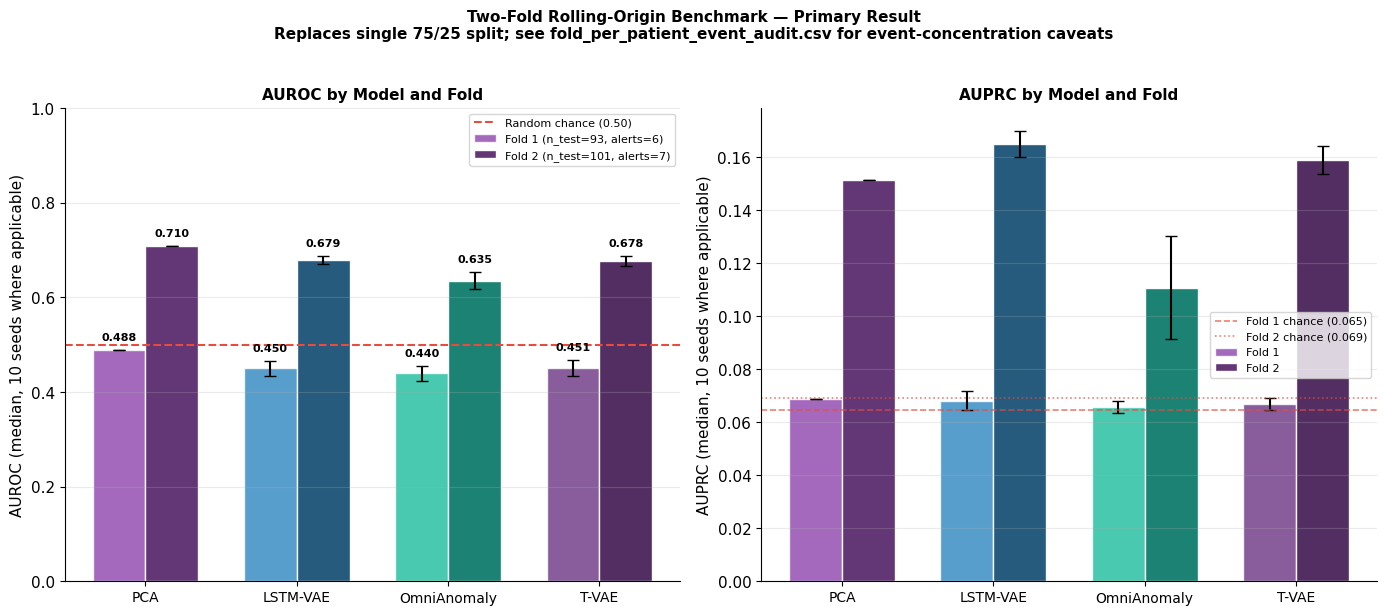

Saved fig8_rolling_origin_benchmark.pdf


In [40]:
# ── FIGURE 8: ROLLING-ORIGIN BENCHMARK (PRIMARY RESULT) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Two-Fold Rolling-Origin Benchmark — Primary Result\n'
    'Replaces single 75/25 split; see fold_per_patient_event_audit.csv for '
    'event-concentration caveats',
    fontsize=11, fontweight='bold', y=1.02
)

models = ['PCA', 'LSTM-VAE', 'OmniAnomaly', 'T-VAE']
x = np.arange(len(models))
width = 0.35
colors_f1 = ['#8E44AD', '#2E86C1', '#1ABC9C', '#6C3483']
colors_f2 = ['#5B2C6F', '#1A5276', '#0F7B6C', '#4A235A']

fold1_auroc = [rolling_origin_df[rolling_origin_df.Model == m]['Fold 1 AUROC'].values[0] for m in models]
fold1_std   = [rolling_origin_df[rolling_origin_df.Model == m]['Fold 1 AUROC std'].values[0] for m in models]
fold2_auroc = [rolling_origin_df[rolling_origin_df.Model == m]['Fold 2 AUROC'].values[0] for m in models]
fold2_std   = [rolling_origin_df[rolling_origin_df.Model == m]['Fold 2 AUROC std'].values[0] for m in models]

fold1_auprc = [rolling_origin_df[rolling_origin_df.Model == m]['Fold 1 AUPRC'].values[0] for m in models]
fold1_auprc_std = [rolling_origin_df[rolling_origin_df.Model == m]['Fold 1 AUPRC std'].values[0] for m in models]
fold2_auprc = [rolling_origin_df[rolling_origin_df.Model == m]['Fold 2 AUPRC'].values[0] for m in models]
fold2_auprc_std = [rolling_origin_df[rolling_origin_df.Model == m]['Fold 2 AUPRC std'].values[0] for m in models]

# Panel 1: AUROC
ax = axes[0]
ax.bar(x - width/2, fold1_auroc, width, yerr=fold1_std, color=colors_f1,
       alpha=0.8, edgecolor='white', capsize=4, error_kw={'lw': 1.5},
       label=f"Fold 1 (n_test={fold_pools['Fold 1']['X_test'].shape[0]}, "
             f"alerts={int(fold_pools['Fold 1']['y_test'].sum())})")
ax.bar(x + width/2, fold2_auroc, width, yerr=fold2_std, color=colors_f2,
       alpha=0.95, edgecolor='white', capsize=4, error_kw={'lw': 1.5},
       label=f"Fold 2 (n_test={fold_pools['Fold 2']['X_test'].shape[0]}, "
             f"alerts={int(fold_pools['Fold 2']['y_test'].sum())})")
ax.axhline(0.5, color='#E74C3C', ls='--', lw=1.5, label='Random chance (0.50)')
ax.set_xticks(x); ax.set_xticklabels(models, fontsize=10)
ax.set_ylabel('AUROC (median, 10 seeds where applicable)')
ax.set_ylim(0, 1.0)
ax.set_title('AUROC by Model and Fold', fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.25, axis='y')
for i, (v1, v2) in enumerate(zip(fold1_auroc, fold2_auroc)):
    ax.text(x[i]-width/2, v1+fold1_std[i]+0.02, f'{v1:.3f}', ha='center', fontsize=8, fontweight='bold')
    ax.text(x[i]+width/2, v2+fold2_std[i]+0.02, f'{v2:.3f}', ha='center', fontsize=8, fontweight='bold')

# Panel 2: AUPRC
ax = axes[1]
ax.bar(x - width/2, fold1_auprc, width, yerr=fold1_auprc_std, color=colors_f1,
       alpha=0.8, edgecolor='white', capsize=4, error_kw={'lw': 1.5},
       label='Fold 1')
ax.bar(x + width/2, fold2_auprc, width, yerr=fold2_auprc_std, color=colors_f2,
       alpha=0.95, edgecolor='white', capsize=4, error_kw={'lw': 1.5},
       label='Fold 2')
chance_f1 = fold_results_df[(fold_results_df.Fold == 'Fold 1')]['Chance AUPRC'].iloc[0]
chance_f2 = fold_results_df[(fold_results_df.Fold == 'Fold 2')]['Chance AUPRC'].iloc[0]
ax.axhline(chance_f1, color='#E74C3C', ls='--', lw=1.2, alpha=0.7, label=f'Fold 1 chance ({chance_f1:.3f})')
ax.axhline(chance_f2, color='#E74C3C', ls=':', lw=1.2, alpha=0.7, label=f'Fold 2 chance ({chance_f2:.3f})')
ax.set_xticks(x); ax.set_xticklabels(models, fontsize=10)
ax.set_ylabel('AUPRC (median, 10 seeds where applicable)')
ax.set_title('AUPRC by Model and Fold', fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig(FIGPATH / 'fig8_rolling_origin_benchmark.pdf', bbox_inches='tight', dpi=300)
plt.savefig(FIGPATH / 'fig8_rolling_origin_benchmark.png', bbox_inches='tight', dpi=300)
plt.show()
print("Saved fig8_rolling_origin_benchmark.pdf")

In [45]:
# ── SHAP EXPLAINABILITY (PCA and T-VAE, pooled condition) ───────────────────
import shap

def make_pca_score_fn(pca_model):
    def score_fn(X_flat):
        recon = pca_model.inverse_transform(pca_model.transform(X_flat))
        return ((X_flat - recon) ** 2).mean(axis=1)
    return score_fn

def make_tvae_score_fn(model):
    def score_fn(X_flat):
        X_t = torch.tensor(X_flat.reshape(-1, 7, 22), dtype=torch.float32)
        return get_anomaly_scores(model, X_t)
    return score_fn

# Background set: small random sample of pooled NORMAL training windows
rng_shap = np.random.default_rng(0)
bg_idx = rng_shap.choice(len(X_train_pooled), size=min(30, len(X_train_pooled)), replace=False)
background_flat = flatten_windows(X_train_pooled[bg_idx])
X_test_flat = flatten_windows(X_test_pooled)

# Refit PCA at the same training-only k from Step 1, for consistency
pca_k = pca_k90_results[pooled_condition]['n_components']
pca_shap_model = PCA(n_components=pca_k, svd_solver='full')
pca_shap_model.fit(flatten_windows(X_train_pooled))

# Retrain T-VAE once at seed=0 -- a fixed model to explain
tvae_shap_model, _ = train_model(TVAE, X_train_pooled, n_features=22, hidden_dim=32,
                                   latent_dim=12, n_epochs=100, lr=1e-3, seed=0, verbose=False)

score_fns = {
    'PCA':   make_pca_score_fn(pca_shap_model),
    'T-VAE': make_tvae_score_fn(tvae_shap_model),
}

results_shap = {}
for name, score_fn in score_fns.items():
    assert callable(score_fn), f"score_fn for {name} is not callable — got {score_fn!r}"

    explainer = shap.KernelExplainer(score_fn, background_flat)
    explain_idx = np.where(y_test_pooled.numpy() == 1)[0]
    if len(explain_idx) == 0:
        explain_idx = np.arange(min(10, len(X_test_flat)))
    shap_values = explainer.shap_values(X_test_flat[explain_idx], nsamples=100)

    shap_by_day_feature = np.abs(shap_values).reshape(len(explain_idx), 7, 22)
    feature_importance = shap_by_day_feature.sum(axis=1).mean(axis=0)
    results_shap[name] = feature_importance

    print(f"\n{name} — top 5 features (mean |SHAP|, summed across 7-day window, "
          f"{len(explain_idx)} alert windows explained):")
    for rank, fi in enumerate(np.argsort(feature_importance)[::-1][:5], 1):
        print(f"  {rank}. {feature_cols[fi]}: {feature_importance[fi]:.4f}")

shap_summary_df = pd.DataFrame({
    'Feature': feature_cols,
    'PCA_importance': results_shap['PCA'],
    'T-VAE_importance': results_shap['T-VAE'],
}).sort_values('PCA_importance', ascending=False)
shap_summary_df.to_csv(RESPATH / 'table_shap_feature_importance.csv', index=False)
print("\nSaved table_shap_feature_importance.csv")

  0%|          | 0/4 [00:00<?, ?it/s]


PCA — top 5 features (mean |SHAP|, summed across 7-day window, 4 alert windows explained):
  1. phys_heart_rate: 0.0955
  2. act_kitchen: 0.0448
  3. sleep_rem: 0.0433
  4. sleep_light: 0.0407
  5. phys_diastolic_blood_pressure: 0.0406


  0%|          | 0/4 [00:00<?, ?it/s]


T-VAE — top 5 features (mean |SHAP|, summed across 7-day window, 4 alert windows explained):
  1. phys_heart_rate: 0.3589
  2. phys_diastolic_blood_pressure: 0.1825
  3. act_lounge: 0.0963
  4. act_bathroom: 0.0881
  5. sleep_rr: 0.0564

Saved table_shap_feature_importance.csv


## Note: SHAP Feature Importance — Cross-Model Agreement (Standalone Observation)

Explaining PCA and T-VAE's anomaly scores on the 4 confirmed pooled-test alert
windows shows a notable point of agreement despite the two models disagreeing
on overall detection performance:

**Both models independently rank `phys_heart_rate` as the single most
important feature by a wide margin.** T-VAE also ranks
`phys_diastolic_blood_pressure` second, which appears in PCA's top 5 as well
— physiological features dominate the top of both rankings, ahead of
activity-location and sleep-stage features.

**Where the two models diverge is in the secondary features**: PCA's next
ranked features are a mix of activity and sleep (`act_kitchen`, `sleep_rem`,
`sleep_light`), while T-VAE's are different activity locations and a
different sleep metric (`act_lounge`, `act_bathroom`, `sleep_rr`). This
divergence in secondary signal, alongside agreement on the dominant feature,
is consistent with this project's core finding: the models pick up similar
dominant signal but organise residual signal differently, which likely
contributes to why their AUROC ranking is unstable across folds and
resampled test sets.

**Caveat, consistent with every other finding in this evaluation**: this
explanation is built from only **4 alert windows** — the same event-scarcity
constraint that limits every quantitative result in this project. This should
be read as a suggestive, exploratory observation about which sensor
modalities carry discriminative signal for this cohort, not as a validated
or statistically established feature-importance ranking. It is not proof
that heart rate is "the" clinically important feature for dementia-related
anomaly detection — only that, on the small number of confirmed cases
available here, both a simple and a complex model converge on it.